## 1) Import packages

In [3]:
# Packages
import pandas as pd
import re
import numpy as np
import glob
import os
from collections import defaultdict
import networkx
from networkx.algorithms.components.connected import connected_components
from packages import npomix
import time
from datetime import datetime
from sklearn.metrics import jaccard_score
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import pickle
from tqdm import tqdm

#### Important Notes

1. **Modified Code**: Sections marked with **#change** indicate modifications made to the original code. These changes are also reflected in the `npomix.py` file located in `NPOmix_python/packages/`. Additionally, code blocks with **#my_version** comment contain results from the latest code run, allowing for comparison with the original results. 
2. **README File**: For additional information and context, please refer to the README.md file located in `NPOmix_python/updated_notebook`.
3. **New Evaluation Section**: Section 6, "Evaluation with new BGC_GNPS matching file", is a new addition that aims to assess the precision of the model using the updated BGC_GNPS matching file.
4. **Original version**: This section comprises all of the results from the original notebook file. 

In [5]:
!ls ./inputs/

bigscape_results  gnps_function  massql_mgfs  validation_22links_mgfs


## 2) Load data

In [7]:
# Path to the input files 
# Path to the edges file from GNPS molecular networking results
# This file contains spectral similarity relationships between clusters (edges in the network)
# Format: Typically includes columns like CLUSTERID1, CLUSTERID2, CosineScore, etc.
edges_path = "./inputs/gnps_function/96d708b13d1e401fbb2fb58ccbcbc78c..selfloop"

# Path to the nodes file from GNPS clustering results
# This file contains information about each MS/MS spectral cluster
# Format: Includes metadata like cluster index, LibraryID (compound annotations), 
# precursor mass, number of spectra, etc.
nodes_path = "./inputs/gnps_function/c2a89b977ead4342b42900d7023ec110.clustersummary"

In [8]:
# Read the edges and nodes files into pandas DataFrames
edges = pd.read_csv(edges_path, sep="\t")
nodes = pd.read_csv(nodes_path, sep="\t")
# Display the first few rows of the edges DataFrame
print("Edges DataFrame:")
display(edges.head())
# Display the first few rows of the nodes DataFrame
print("Nodes DataFrame:")
display(nodes.head())
# Check the shape of the edges DataFrame
print(f'Shape of edges: {edges.shape}')
# Check the shape of the nodes DataFrame
print(f'Shape of nodes: {nodes.shape}')

/tmp/ipykernel_1908858/1462610830.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  edges = pd.read_csv(edges_path, sep="\t")


Edges DataFrame:


,CLUSTERID1,CLUSTERID2,DeltaMZ,MEH,Cosine,OtherScore,ComponentIndex,EdgeAnnotation
0,559657,559676,-0.001,559657.0,0.8537,559657.0,2,
1,559590,559651,-0.002,559590.0,0.8149,559590.0,2,
2,559651,559657,0.000,559651.0,0.8563,559651.0,2,
3,559651,559676,-0.001,559651.0,0.8553,559651.0,2,
4,2152609,2152610,-0.321,2152609.0,0.9176,2152609.0,4,


Nodes DataFrame:


,AllGroups,DefaultGroups,EvenOdd,G1,G2,G3,G4,G5,G6,GNPSLinkout_Cluster,...,SpectrumID,UniqueFileSources,UniqueFileSourcesCount,cluster index,componentindex,number of spectra,parent mass,precursor charge,precursor mass,sum(precursor intensity)
0,,G1,1,8,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Blongum44Bv1.3.mzXML|Bact_sp_9_1_42FAA_V2.3.mz...,7,2,-1,8,84.043,0,84.043,12004.0
1,,G1,1,14,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM6v1.2.mzXML|Bact_cacc_CL03T12C61_V1.3.mzX...,12,3,-1,14,84.043,0,84.043,23389.0
2,,G1,1,4,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Acti_vis_C505_V3.3.mzXML|Bact_sp_1_1_6_V2.3.mz...,4,5,-1,4,84.043,0,84.043,8576.0
3,,G1,1,21,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM7v1.2.mzXML|SspCM6v1.2.mzXML|Bact_cacc_CL...,12,6,1488,21,84.044,0,84.044,48410.0
4,,G1,1,15,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Bact_cacc_CL03T12C61_V1.3.mzXML|Bact_sp_9_1_42...,12,11,1488,15,84.043,0,84.043,35506.0


Shape of edges: (219318, 8)
Shape of nodes: (186163, 29)


In [9]:
# Read the nodes file 
nodes_df = pd.read_csv(nodes_path,sep='\t')
nodes_df.head()

,AllGroups,DefaultGroups,EvenOdd,G1,G2,G3,G4,G5,G6,GNPSLinkout_Cluster,...,SpectrumID,UniqueFileSources,UniqueFileSourcesCount,cluster index,componentindex,number of spectra,parent mass,precursor charge,precursor mass,sum(precursor intensity)
0,,G1,1,8,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Blongum44Bv1.3.mzXML|Bact_sp_9_1_42FAA_V2.3.mz...,7,2,-1,8,84.043,0,84.043,12004.0
1,,G1,1,14,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM6v1.2.mzXML|Bact_cacc_CL03T12C61_V1.3.mzX...,12,3,-1,14,84.043,0,84.043,23389.0
2,,G1,1,4,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Acti_vis_C505_V3.3.mzXML|Bact_sp_1_1_6_V2.3.mz...,4,5,-1,4,84.043,0,84.043,8576.0
3,,G1,1,21,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM7v1.2.mzXML|SspCM6v1.2.mzXML|Bact_cacc_CL...,12,6,1488,21,84.044,0,84.044,48410.0
4,,G1,1,15,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Bact_cacc_CL03T12C61_V1.3.mzXML|Bact_sp_9_1_42...,12,11,1488,15,84.043,0,84.043,35506.0


In [10]:
# Initialize an empty list to store cluster indices of annotated compounds
clusterindex_list = []

# Iterate through each row in the nodes DataFrame using iterrows()
# i = row index, r = row data (as a Series)
for i, row in nodes_df.iterrows():
    # Check if the LibraryID value is not a float (i.e., not NaN/missing)
    # In pandas, missing values are typically represented as float('nan')
    if type(row['LibraryID']) != float:
        # If LibraryID exists (has an annotation), add the cluster index to our list
        clusterindex_list.append(row['cluster index'])

print(f'clusterindex list (MS spectra): \n {clusterindex_list}')

clusterindex list (MS spectra): 
 [5668, 7209, 10731, 10732, 10763, 11459, 11636, 11637, 11963, 12071, 12082, 12132, 12163, 12578, 12823, 12830, 13100, 13395, 13499, 13518, 13708, 15307, 16294, 16716, 16853, 16854, 17578, 18379, 18470, 20508, 20714, 22725, 24958, 25004, 25026, 25059, 25150, 25291, 25633, 25634, 25639, 25649, 26097, 26110, 26114, 27121, 27357, 27522, 27631, 27632, 27634, 27921, 28039, 28267, 28506, 28530, 28531, 28558, 28600, 28634, 28672, 28675, 28799, 28834, 28882, 28897, 29029, 29788, 29793, 29856, 29968, 30020, 30034, 30056, 30080, 30107, 30112, 30157, 30260, 30285, 30317, 31054, 31526, 31656, 31714, 32103, 32153, 32155, 32160, 32163, 32178, 32181, 33168, 33195, 33254, 33284, 33332, 33717, 34458, 35036, 35127, 35235, 35239, 35244, 35252, 35343, 35434, 35447, 35614, 35710, 35848, 36035, 36109, 36117, 36211, 36534, 36689, 36806, 36962, 37367, 40007, 40378, 40526, 40732, 40763, 40764, 40767, 40866, 41055, 41335, 41339, 42484, 42520, 42528, 42573, 42701, 42704, 42706, 4

In [11]:
annotated_cluster_indices = list(nodes_df[nodes_df['LibraryID'].notna()]['cluster index'].unique())
print(f"Unique annotated clusters: {len(annotated_cluster_indices)}")

Unique annotated clusters: 14171


In [12]:
# Show only those library IDs that are not NaN
annotated_library_ids = nodes_df[nodes_df['LibraryID'].notna()]['LibraryID'].unique()
print(f"Annotated Library IDs: {annotated_library_ids}")


Annotated Library IDs: ['Levulinic acid - 40.0 eV' 'Benzoic acid' 'Metformin - 30.0 eV' ...
 'Indolactam derivative C28H37N3O2 related to Lyngbyatoxin A'
 'NCGC00385686-01!3-(2,4-dihydroxyphenyl)-5,7-dihydroxy-6,8-bis(3-methylbut-2-enyl)chromen-4-one'
 'N-[4,5-dihydroxy-6-(hydroxymethyl)-2-(4-methyl-2-oxochromen-7-yloxy)-2H-3,4,5, 6-tetrahydropyran-3-yl]acetamide CollisionEnergy:205060']


In [13]:
# number of unique clusters
unique_clusters = len(set(clusterindex_list))
print(f'Number of unique clusters (spectra): {unique_clusters}')

Number of unique clusters (spectra): 14171


In [14]:
nodes_df.columns

Index(['AllGroups', 'DefaultGroups', 'EvenOdd', 'G1', 'G2', 'G3', 'G4', 'G5',
       'G6', 'GNPSLinkout_Cluster', 'GNPSLinkout_Network', 'LibraryID',
       'MQScore', 'MZErrorPPM', 'MassDiff', 'RTMean', 'RTMean_min', 'RTStdErr',
       'Smiles', 'SpectrumID', 'UniqueFileSources', 'UniqueFileSourcesCount',
       'cluster index', 'componentindex', 'number of spectra', 'parent mass',
       'precursor charge', 'precursor mass', 'sum(precursor intensity)'],
      dtype='object')

In [ ]:
# Read the edges file
edges_df = pd.read_csv(edges_path, sep='\t', low_memory=False)

## 3) Functions 

In [17]:

def get_neighbors(target, dataframe, column1, column2):
    """"
    Returns a list of all neighbors of a target node in a graph defined by two columns of a DataFrame
    """
    # Subset rows where target appears in either column
    subset1 = dataframe[(dataframe[column1] == target)]
    # change: I commented out the line below 
    # subcat = subset1.append(dataframe[(dataframe[column2] == target)])
    subset2 = dataframe[(dataframe[column2] == target)]
    subcat = pd.concat([subset1, subset2])
    
    temp_list = []
    # Extract all values connected to the target
    for index, row in subcat.iterrows():
        temp_list.append(subcat[column1][index])
        temp_list.append(subcat[column2][index])
    
    # Remove duplicates and return the list of unique neighbors
    temp_list = list(np.unique(temp_list))
    return temp_list

# Example: [A, B, C] → [(A, B), (B, C)]
def to_edges(l):
    """
    Converts a list into consecutive edges
    """
    it = iter(l)
    last = next(it)
    for current in it:
        yield last, current
        last = current

# Each sublist is treated as a linear path of connected nodes
def to_graph(l):
    """
    Converts a list of lists of nodes into a NetworkX graph
    """
    G = networkx.Graph()
    for part in l:
        G.add_nodes_from(part)            # Add nodes
        G.add_edges_from(to_edges(part))  # Add edges between consecutive nodes
    return G

def get_family_dict(components_list, dataframe, dictionary, column1, column2, column3):
    """
    Returns a dictionary mapping connected components (families) to their members
    """
    count = 0
    for family in list(components_list):
        count += 1
        for fam_member in family:
            dictionary['MF%s' % count].append(fam_member)   # Add family member to the dictionary
    return dictionary

# Main function to extract families (connected components) from GNPS edge data
def main_get_families(gnps_df):
    # Get unique node (spectrum) IDs from both columns
    targets_list = np.unique([gnps_df.CLUSTERID1, gnps_df.CLUSTERID2])

    neighbors_list = []  # Initialize an empty list to store neighbors of each target node (list of lists)
    # For each node, get its neighbors
    for target in tqdm(targets_list, desc="Getting neighbors:"):
        neighbors_list.append(get_neighbors(target, gnps_df, 'CLUSTERID1', 'CLUSTERID2'))
    
    # Create graph and get its connected components
    G = to_graph(neighbors_list)
    C = connected_components(G)  # Yields sets of connected nodes
    
    # Build dictionary of molecular families
    mf_dict = defaultdict(list)
    mf_dict = get_family_dict(C, gnps_df, mf_dict, 'CLUSTERID1', 'CLUSTERID2', 'Cosine')
    return mf_dict


In [12]:
# Run the family detection function on the input DataFrame
mf_dict = main_get_families(edges_df)

# Display the result: dictionary of molecular families and their members
mf_dict

Getting neighbors:: 100%|██████████| 186163/186163 [08:23<00:00, 369.56it/s]


defaultdict(list,
            {'MF1': [2],
             'MF2': [3],
             'MF3': [5],
             'MF4': [5604,
              15876,
              6,
              3784,
              177928,
              11,
              12204,
              15884,
              64785,
              3987,
              5589,
              6421,
              87671,
              2128764,
              64829,
              3806],
             'MF5': [18],
             'MF6': [36],
             'MF7': [47],
             'MF8': [63],
             'MF9': [384],
             'MF10': [473],
             'MF11': [731],
             'MF12': [732],
             'MF13': [733],
             'MF14': [734],
             'MF15': [741],
             'MF16': [742],
             'MF17': [743],
             'MF18': [745, 5075, 3357, 3783],
             'MF19': [753],
             'MF20': [1153],
             'MF21': [1354],
             'MF22': [1416],
             'MF23': [13128, 3316, 174591],
             

Code summary:
- This code identifies connected components in a graph where nodes are GNPS spectral clusters (CLUSTERID1, CLUSTERID2) and edges represent similarities (e.g. cosine score).

- The result is a dictionary (mf_dict) where each key (MF1, MF2, ...) corresponds to a molecular family, and the value is a list of GNPS cluster IDs belonging to that family.

- It’s especially useful for grouping MS/MS spectra into families (MF) based on their spectral similarity network. For example, MS spectra 5604, 15876, ... form a molecular family, MF4, in the above example. 

#### Save/load mf_dict

In [18]:
# Path to the output files 
base_output_path = "/home/fab25/NPOmix_python"
output_path = os.path.join(base_output_path, "saved_files")

# # Save to file
# with open(os.path.join(output_path, 'mf_dict.pkl'), 'wb') as f:
#     pickle.dump(mf_dict, f)

# Load from file
with open(os.path.join(output_path, 'mf_dict.pkl'), 'rb') as f:
    mf_dict = pickle.load(f)


In [21]:
nodes_df['UniqueFileSources']

0         Blongum44Bv1.3.mzXML|Bact_sp_9_1_42FAA_V2.3.mz...
1         SspCM6v1.2.mzXML|Bact_cacc_CL03T12C61_V1.3.mzX...
2         Acti_vis_C505_V3.3.mzXML|Bact_sp_1_1_6_V2.3.mz...
3         SspCM7v1.2.mzXML|SspCM6v1.2.mzXML|Bact_cacc_CL...
4         Bact_cacc_CL03T12C61_V1.3.mzXML|Bact_sp_9_1_42...
                                ...                        
186158    2537561678.4.mzXML|2529292847.4.mzXML|25375618...
186159    GCA_000020025.23.mzXML|DS570624.17.mzML|GCA_00...
186160    ERS4341426.1.mzXML|ERS4341402.1.mzXML|ERS43415...
186161                                GCA_001625105.2.mzXML
186162    GCA_900155985.4.mzML|GCA_000744555.4.mzML|GCA_...
Name: UniqueFileSources, Length: 186163, dtype: object

In [22]:
# Initialize an empty list to store unique LC-MS file names
lcms_file_list = []

# Iterate over each entry in the 'UniqueFileSources' column of the nodes_df DataFrame
for item in nodes_df['UniqueFileSources']:
    
    # Each item may contain multiple file names separated by '|'
    # So we split the string into individual file names
    for lcms_file in item.split('|'):
        
        # If the LC-MS file is not already in the list, add it
        if lcms_file not in lcms_file_list:
            print(lcms_file)                # Optionally print the new file name
            lcms_file_list.append(lcms_file)  # Add it to the list

Blongum44Bv1.3.mzXML
Bact_sp_9_1_42FAA_V2.3.mzXML
SspSR1v1.2.mzXML
Clos_orbi_1_3_50AFAA_V1.3.mzXML
Clos_clos_2_1_49FAA_V1.3.mzXML
SspCM7v1.2.mzXML
Bact_vulg_CL09T03C04_V1.3.mzXML
SspCM6v1.2.mzXML
Bact_cacc_CL03T12C61_V1.3.mzXML
SspOBRC6v1.2.mzXML
Bact_frag_CL07T12C05_V1.3.mzXML
Para_merd_CL03T12C32_V1.3.mzXML
Bact_dore_CL02T00C15_V1.3.mzXML
Clos_bact_OBRC5-5_V1.2.mzXML
Bacteroides_sp_1_1_30_V1.3.mzXML
Acti_vis_C505_V3.3.mzXML
Bact_sp_1_1_6_V2.3.mzXML
Bact_cell_CL02T12C19_V1.3.mzXML
Bact_frag_CL07T00C01_V1.3.mzXML
Bact_ster_CC31F_V1.3.mzXML
Bact_thet_CL09T03C10_V1.3.mzXML
GCA_001625105.1.mzXML
GCA_000012265.1.mzXML
BspMSTE12v1.3.mzXML
Bact_dore_CL02T12C06_V1.3.mzXML
Bifi_brev_HPH0326_V1.3.mzXML
Para_merd_CL09T00C40_V1.3.mzXML
GCA_001562525.1.mzXML
GCA_000506385.2.mzXML
GCA_003324555.1.mzXML
Blongum35Bv1.3.mzXML
SspBS29av1.2.mzXML
Bact_frag_CL03T12C07_V1.3.mzXML
ERX2291258.1.mzXML
ERX2291789.1.mzXML
ERX2291921.1.mzXML
ERX2291699.1.mzXML
Kleb_pneu_WGLW2_V1.1.mzXML
GCA_012367695.5.mzXML
GC

In [23]:
# print the number of nodes 
print("Number of nodes (MS spectra): ", len(nodes_df))
print(f'Number of unique LC-MS files: {len(lcms_file_list)}')

Number of nodes (MS spectra):  186163
Number of unique LC-MS files: 2982


In [25]:
# change: ion is added as a parameter 
def get_presence_files(nodes_df, ion):
    """ 
    Returns a list of LC-MS files in which a given ion (spectral cluster) is present
    """
    # For the given ion (assumed to be globally defined in the outer loop),
    # find the 'UniqueFileSources' entry where 'cluster index' matches the ion
    for unique_list in list(nodes_df[nodes_df['cluster index'] == ion]['UniqueFileSources']):
        # Split the string of file names separated by '|' into a list.
        # This assumes each ion can be present in multiple files.
        # Every ion can be present in multiple files, but we only need the first match.
        return list(unique_list.split('|'))  

# Initialize empty lists to store results
all_rows_list = []         # Stores the cosine value vector for each ion
testing_indexes_list = []  # Stores the list of ions processed (used as DataFrame index)


In [26]:
# Loop through each ion (cluster index) to generate the feature vector
for ion in tqdm(clusterindex_list, desc="Generating feature vectors:"):
    
    # Filter edges that involve the current ion (from either column)
    subset_edges = edges_df[(edges_df.CLUSTERID1 == ion) | (edges_df.CLUSTERID2 == ion)]
    
    # Extract the highest cosine similarity score for the ion, rounded to 2 
    # This cosine value is not per sample, it is per node (across all data). Every node which is made of several samples will have a single cosine value.
    # The cosine value represents the maximum similarity score of the ion with any other ion in the network. 
    cosine = round(max(subset_edges['Cosine']), 2)
    
    # Get the list of LC-MS files in which the current ion is present
    presence_list = get_presence_files(nodes_df, ion)
    
    single_row_list = []  # Will contain the cosine values for each LC-MS file for this ion
    
    # Loop through each LC-MS file in the global list
    for lcms_file in lcms_file_list:
        # If the LC-MS file is in the presence list, append the cosine value
        # Otherwise, append 0 (indicating absence)
        single_row_list.append(cosine if lcms_file in presence_list else 0)
    
    # Add the row vector to the full matrix and track the ion
    all_rows_list.append(single_row_list)
    testing_indexes_list.append(ion)
# Create a DataFrame from the cosine matrix
# Rows: ions (cluster indexes), Columns: LC-MS files
pre_testing_df = pd.DataFrame(all_rows_list, index=testing_indexes_list, columns=lcms_file_list)

# Display the resulting matrix
pre_testing_df

Generating feature vectors:: 100%|██████████| 14171/14171 [00:42<00:00, 330.82it/s]


,Blongum44Bv1.3.mzXML,Bact_sp_9_1_42FAA_V2.3.mzXML,SspSR1v1.2.mzXML,Clos_orbi_1_3_50AFAA_V1.3.mzXML,Clos_clos_2_1_49FAA_V1.3.mzXML,SspCM7v1.2.mzXML,Bact_vulg_CL09T03C04_V1.3.mzXML,SspCM6v1.2.mzXML,Bact_cacc_CL03T12C61_V1.3.mzXML,SspOBRC6v1.2.mzXML,...,GCA_012367695.4.mzXML,GCA_000377145.7.mzXML,2517434008.3.mzXML,GCA_000020025.18.mzXML,GCA_000020025.16.mzXML,GCA_000020025.14.mzXML,GCA_000020025.10.mzXML,GCA_000020025.5.mzXML,GCA_000020025.8.mzXML,GCA_000020025.12.mzXML
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2710471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The dataset is called `pre_testing_df` because it's the precursor to the actual "testing fingerprint matrix" used in the NPOmix pipeline.

It’s pre-processed input data for testing

After some renaming/filtering steps (like npomix.get_testing_df(...)), this matrix is used to:

- Compare MS fingerprints to genomic fingerprints

- Run KNN to predict BGC-GCF matches

#### Save/load pre_testing_df

In [27]:
# Save and load the pre-testing DataFrame
# # Save the DataFrame to a pickle file
# pre_testing_df.to_pickle(os.path.join(output_path, 'pre_testing_df.pkl'))

# Load the DataFrame from the pickle file
pre_testing_df = pd.read_pickle(os.path.join(output_path, 'pre_testing_df.pkl'))

In [28]:
pre_testing_df

,Blongum44Bv1.3.mzXML,Bact_sp_9_1_42FAA_V2.3.mzXML,SspSR1v1.2.mzXML,Clos_orbi_1_3_50AFAA_V1.3.mzXML,Clos_clos_2_1_49FAA_V1.3.mzXML,SspCM7v1.2.mzXML,Bact_vulg_CL09T03C04_V1.3.mzXML,SspCM6v1.2.mzXML,Bact_cacc_CL03T12C61_V1.3.mzXML,SspOBRC6v1.2.mzXML,...,GCA_012367695.4.mzXML,GCA_000377145.7.mzXML,2517434008.3.mzXML,GCA_000020025.18.mzXML,GCA_000020025.16.mzXML,GCA_000020025.14.mzXML,GCA_000020025.10.mzXML,GCA_000020025.5.mzXML,GCA_000020025.8.mzXML,GCA_000020025.12.mzXML
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2710471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
# Function to generate a final DataFrame summarizing MS-BGC matches
def get_final_df(training_df, testing_df, neighbors_array, results_folder):
    """
    Generates a DataFrame summarizing metabolite–BGC matches based on fingerprint similarity.
    
    Parameters:
    - training_df: DataFrame containing BGC fingerprints and their labels.
    - testing_df: DataFrame containing metabolite fingerprints (MS features).
    - neighbors_array: A 2D list where each row contains predicted BGCs (labels) for a metabolite.
    - results_folder: Path to save results if needed.

    Returns:
    - final_df: A DataFrame with one row per metabolite summarizing top predicted GCF and metadata.
    """
    # Initialize an empty DataFrame with predefined columns
    final_df = pd.DataFrame(columns=(
        'metabolite_ID',    # GNPS cluster ID (CCMS ID)
        'predicted_GCF',    # List of predicted gene cluster families (GCFs)
        'max_jaccard',      # Maximum Jaccard similarity score across neighbors
        'parent_mass',      # Precursor ion mass for the metabolite
        'sum_intensity',    # Sum of precursor intensities
        'GNPS_lib_hit'      # GNPS library match ID (if available)
    ))

    # Loop over each metabolite (row) in the testing DataFrame
    for i, ccms_id in enumerate(testing_df.index):

        jaccard_scores = []  # Will store Jaccard scores with each neighbor BGC

        # For each predicted GCF (neighbor) of the current metabolite
        for j in range(0, len(neighbors_array[i])):
            query_bgc = neighbors_array[i][j]  # GCF label
            
            # Get the fingerprint vector for the BGC from the training data
            bgc_fp = training_df[training_df['label'] == query_bgc].iloc[0]
            bgc_fp = bgc_fp.drop("label")  # Remove the label column for comparison
            
            # Get the fingerprint vector for the metabolite from the testing data
            ms_fp = testing_df.loc[ccms_id]

            # Convert both BGC and MS fingerprints to binary vectors
            bgc_binary = npomix.get_binary(bgc_fp)
            ms_binary = npomix.get_binary(ms_fp)

            # Compute Jaccard similarity between the MS and BGC binary fingerprints
            jaccard_scores.append(jaccard_score(bgc_binary, ms_binary))

        # Get the maximum Jaccard similarity score across all neighbors
        max_jaccard = round(max(jaccard_scores), 2)

        # Extract metadata for the metabolite from the GNPS nodes table
        parentmass = nodes_df[nodes_df['cluster index'] == ccms_id]['precursor mass'].item()
        intensity = nodes_df[nodes_df['cluster index'] == ccms_id]['sum(precursor intensity)'].item()
        libhit = nodes_df[nodes_df['cluster index'] == ccms_id]['LibraryID'].item()

        # Add a new row to the final results DataFrame
        final_df.loc[i] = (
            ccms_id,               # Metabolite ID
            neighbors_array[i],   # List of predicted GCFs
            max_jaccard,          # Highest Jaccard score
            parentmass,           # Precursor mass
            intensity,            # Total intensity
            libhit                # GNPS library match
        )

    # Optional: Save to file (currently commented out)
    # final_df.to_csv("%sfinal_df-derep-NPOmix1.0-%s.txt"%(results_folder, current_date), sep="\t", index_label=False)

    return final_df  # Return the result table


Code summary:
- This function matches each metabolite spectrum in testing_df to its predicted GCFs from training_df.

- It computes Jaccard similarity scores between MS and BGC fingerprints using a method from the npomix module.

- Metadata like precursor mass, intensity, and library hits are added from nodes_df.

- The result is a summary table of predicted MS–BGC matches, which can optionally be saved to disk.

In [30]:
# Function to find the k nearest neighbors for each testing sample using k-NN on binary fingerprints
def running_knn(training_df, testing_df, k_value):
    """"
    Finds the k nearest neighbors for each testing sample using k-NN on binary fingerprints.
    
    Parameters:
    - training_df: DataFrame containing BGC fingerprints and their labels.
    - testing_df: DataFrame containing metabolite fingerprints (MS features).
    - k_value: Number of nearest neighbors to find for each testing sample.

    Returns:
    - neighbors_array: A 2D list where each row contains predicted BGCs (labels) for a metabolite.
    """
    # Extract the feature matrix (X) from the training data by dropping the label column
    X_div = training_df.drop("label", axis=1)
    
    # # Convert column names to strings to avoid any numeric type issues
    # X_div.columns = X_div.columns.astype(str)
    # # change: I added the bottom line 
    # testing_df.columns = testing_df.columns.astype(str)  # Also fix test input

    # change: 
    # Fix column names for sklearn compatibility
    X_div.columns = [str(col) for col in X_div.columns]
    testing_df.columns = [str(col) for col in testing_df.columns]


    # Extract the label vector (y), which holds the class or cluster info (e.g. BGC family)
    y_div = training_df["label"]
    

    # Initialize and fit a k-Nearest Neighbors model
    # nbrs = NearestNeighbors(n_neighbors=k_value, algorithm='ball_tree').fit(X_div, y_div)
    # change: I added the below line and the commented line above 
    nbrs = NearestNeighbors(n_neighbors=k_value, algorithm='ball_tree').fit(X_div)

    
    # Use the trained model to find the k nearest neighbors for each sample in the test set
    # indices: a list of lists where each inner list contains indices of the k nearest neighbors for a test sample
    distances, indices = nbrs.kneighbors(testing_df)
    
    # Reset index to ensure that y_div and indices align properly
    y_div = y_div.reset_index(drop=True)
    
    neighbors_array = []  # Will store the labels of k-nearest neighbors for each test sample
    
    # Loop through the list of indices of neighbors for each test instance
    for item in indices:
        candidate_list = []
        for i in range(k_value):
            # Append the label (from y_div) of each neighbor to the candidate list
            candidate_list.append(y_div[item[i]])
        neighbors_array.append(candidate_list)  # Add the list of k neighbors for current test sample
    
    # Convert the final list of lists to a NumPy array
    neighbors_array = np.asarray(neighbors_array)
    
    return neighbors_array  # Return the array of predicted neighbor labels for each test sample


In [20]:
# def running_knn(training_df,testing_df,k_value):
#     X_div = training_df.drop("label", axis=1)
#     X_div.columns = X_div.columns.astype(str)
#     y_div = training_df["label"]
#     nbrs = NearestNeighbors(n_neighbors=k_value, algorithm='ball_tree').fit(X_div,y_div)
#     distances, indices = nbrs.kneighbors(testing_df)
#     y_div = y_div.reset_index(drop=True)
#     neighbors_array = []
#     for item in indices:
#         candidate_list = []
#         for i in range(k_value):
#             candidate_list.append(y_div[item[i]])
#         neighbors_array.append(candidate_list)
#     neighbors_array = np.asarray(neighbors_array)
#     return neighbors_array

In [32]:
# Make a directory to store the results (with python code)

!mkdir ./latest_results

mkdir: cannot create directory ‘./latest_results’: File exists


In [33]:
# Reload the npomix package
import importlib
import packages.npomix
importlib.reload(packages.npomix)


<module 'packages.npomix' from '/home/fab25/NPOmix_python/packages/npomix.py'>

## 4) Running model 
### 1) File and directory setup 


In [34]:
# Mapping file between ENA Run IDs and Experiment IDs (used to align metabolomics and genomics)
ena_df_file = "./ena_dict-210315.csv"
# BiG-SCAPE network output that contains pairwise distances between predicted BGCs
input_bigscape_net = "./bigscape_all_c030.txt"
# Directory containing annotated BGCs in GenBank format from antiSMASH (used for training)
antismash_folder = "./test/antismash_only_gbk/"
# Folder where output results will be saved
results_folder = "./latest_results/test_validation_derep-230406/"

### 2) Metabolomics preprocessing

In [35]:
pre_testing_df

,Blongum44Bv1.3.mzXML,Bact_sp_9_1_42FAA_V2.3.mzXML,SspSR1v1.2.mzXML,Clos_orbi_1_3_50AFAA_V1.3.mzXML,Clos_clos_2_1_49FAA_V1.3.mzXML,SspCM7v1.2.mzXML,Bact_vulg_CL09T03C04_V1.3.mzXML,SspCM6v1.2.mzXML,Bact_cacc_CL03T12C61_V1.3.mzXML,SspOBRC6v1.2.mzXML,...,GCA_012367695.4.mzXML,GCA_000377145.7.mzXML,2517434008.3.mzXML,GCA_000020025.18.mzXML,GCA_000020025.16.mzXML,GCA_000020025.14.mzXML,GCA_000020025.10.mzXML,GCA_000020025.5.mzXML,GCA_000020025.8.mzXML,GCA_000020025.12.mzXML
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2710471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
k_value = 3

# Convert pre_testing_df into merged ispec matrix by consolidating samples from the same strain (MS fingerprint matrix across LC-MS samples)
merged_ispec_mat = npomix.get_merged_ispec_mat(pre_testing_df)
# Rename MS file columns using ENA dictionary (maps LC-MS files to genome identifiers)
merged_ispec_mat = npomix.renaming_merged_ispec_mat(ena_df_file, merged_ispec_mat)

/home/fab25/NPOmix_python/packages/npomix.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = ispec_temp.loc[ispec_temp.index[0], :].values.tolist()
/home/fab25/NPOmix_python/packages/npomix.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = ispec_temp.loc[ispec_temp.index[0], :].values.tolist()
/home/fab25/NPOmix_python/packages/npomix.py:197: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

In [36]:
pre_testing_df.shape

(14171, 2982)

In [27]:
merged_ispec_mat

,Blongum44Bv1,Bact_sp_9_1_42FAA_V2,SspSR1v1,Clos_orbi_1_3_50AFAA_V1,Clos_clos_2_1_49FAA_V1,SspCM7v1,Bact_vulg_CL09T03C04_V1,SspCM6v1,Bact_cacc_CL03T12C61_V1,SspOBRC6v1,...,2516143022,2517572194,GCA_000424965,2548876909,2548876972,2517434008,GCA_001854205,2751185827,2821485673,GCA_000087965
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2710471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710780,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710856,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2710871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3) Genomics preprocessing

In [43]:
print('Obtaining BiG-SCAPE dataframe and BiG-SCAPE dictionary')

# Parse BiG-SCAPE network file into a DataFrame and dictionary of gene cluster families (GCFs)
bigscape_df, bigscape_dict = npomix.parse_bigscape_df(ena_df_file, input_bigscape_net)

# Standardize BGC names using antiSMASH filenames and update GCF dictionary accordingly
bigscape_df, bigscape_dict2 = npomix.rename_bigscape_df(antismash_folder, bigscape_df, bigscape_dict)

print('BiG-SCAPE create with %s GCFs' % len(bigscape_dict))

# Get list of genomes (strains) and BGC identifiers for later matrix alignment
strain_list, bgcs_list = npomix.get_strain_list(bigscape_df)

Obtaining BiG-SCAPE dataframe and BiG-SCAPE dictionary
DEBUG: dictionary type is <class 'collections.defaultdict'>
BiG-SCAPE create with 997 GCFs


In [40]:
output_path

'/home/fab25/NPOmix_python/saved_files'

In [41]:
# Save bigscape_dict2 as pkl file

# with open(os.path.join(output_path, 'bigscape_dict2.pkl'), 'wb') as f:
#     pickle.dump(bigscape_dict2, f)
    
# Read it back in
# with open(os.path.join(output_path, 'bigscape_dict2.pkl'), 'rb') as f:
#     bigscape_dict2 = pickle.load(f)



In [44]:
list(bigscape_dict.items())[:2]

[('GCF1',
  ['JMCC02000121.1.region001',
   'ABCS01000001.1.region002',
   'PVNK01000177.1.region001',
   'PVNL01000058.1.region001']),
 ('GCF2',
  ['BGC0000319.1',
   'BGC0000845.1',
   'ABJH01000008.1.region001',
   'BGC0000844.1'])]

In [45]:
list(bigscape_dict2.items())[:2]

[('GCF1',
  ['GCA_000737335.region031',
   'GCA_000170895.region002',
   'GCA_002994615.region022',
   'GCA_002994635.region018']),
 ('GCF2',
  ['BGC0000319.1', 'BGC0000845.1', 'DS570624.region002', 'BGC0000844.1'])]

#### Important:
- bigscape_dict has to be used to assign the correct BGC to the respective MS spectrum. 
- It shows which MiBIG BGCs are inside which GCF.  

### 4) Feature matrix construction


In [35]:
print('Creating training dataframe')

# Create a binary matrix of BGCs × strains indicating BGC presence per genome
affinity_df, affinity_bgcs = npomix.get_pre_training_df(bigscape_df, bigscape_dict2, strain_list, bgcs_list)

# Rename rows or columns to unify format across metabolomics/genomics data
affinity_df = npomix.renaming_affinity_df(affinity_df)

# Identify shared LC-MS files (columns) that exist in both MS and BGC matrices
networked_cols = npomix.get_networked_cols(merged_ispec_mat, affinity_df)

# Debug output to understand structure of affinity matrix and overlap with MS
print("affinity_df shape:", affinity_df.shape)
print("affinity_df columns:", list(affinity_df.columns))
print("networked_cols:", networked_cols)

# Build the final training DataFrame for k-NN using shared columns
training_df, training_bgcs = npomix.get_training_df(affinity_df, networked_cols, results_folder, affinity_bgcs)

# Optional: store the list of BGCs used in training
bgcs_df = pd.DataFrame(training_bgcs, columns=['bgcs'])

# Prepare the testing matrix (metabolites) using the same shared LC-MS columns
testing_df = npomix.get_testing_df(merged_ispec_mat, networked_cols, results_folder)

Creating training dataframe
affinity_df shape: (5681, 1171)
affinity_df columns: ['2515154094', '2515154124', '2515154177', '2515154206', '2516143022', '2516493032', '2517287023', '2517434008', '2517572157', '2517572165', '2517572194', '2518285535', '2518285561', '2518285562', '2518285564', '2519103067', '2519103070', '2524614807', '2528311034', '2528311045', '2529292840', '2529292847', '2529292952', '2529292986', '2529293274', '2529293277', '2531839107', '2531839114', '2531839222', '2531839223', '2531839225', '2531839226', '2531839304', '2531839307', '2531839315', '2531839319', '2531839320', '2531839324', '2531839421', '2531839422', '2531839423', '2531839424', '2531839425', '2531839426', '2531839427', '2531839428', '2531839429', '2531839430', '2534681797', '2534681798', '2534682005', '2537561578', '2537561580', '2537561581', '2537561582', '2537561583', '2537561586', '2537561671', '2537561673', '2537561674', '2537561675', '2537561676', '2537561677', '2537561678', '2537561681', '2537561

/home/fab25/NPOmix_python/packages/npomix.py:694: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  training_df['label'] = filt_label_col


#### Save/load training_df and bgcs_df

In [47]:
# # Save the training_df and bgcs_df to files for later use as pickle files
# training_df.to_pickle(os.path.join(output_path, 'training_df.pkl'))
# bgcs_df.to_pickle(os.path.join(output_path, 'bgcs_df.pkl'))

# Load the training DataFrame and BGCs from pickle files if needed
training_df = pd.read_pickle(os.path.join(output_path, 'training_df.pkl'))
bgcs_df = pd.read_pickle(os.path.join(output_path, 'bgcs_df.pkl'))
print(f"Shape of the training dataframe: {training_df.shape}")

Shape of the training dataframe: (3502, 981)


#### Save/load testing_df

In [48]:
# # Save the testing_df to a pickle file for later use
# testing_df.to_pickle(os.path.join(output_path, 'testing_df.pkl'))

# Load the testing_df from the pickle file
testing_df = pd.read_pickle(os.path.join(output_path, 'testing_df.pkl'))
print(f"Shape of the testing dataframe: {testing_df.shape}")

Shape of the testing dataframe: (11186, 980)


### 5) Machine Learning Model (k-NN prediction)


In [32]:

print('Running KNN using k equals to %s' % k_value)

# Predict for each metabolite its k nearest BGC neighbors using Jaccard similarity
neighbors_array = running_knn(training_df, testing_df, k_value)

# === Output generation ===

print('Creating final dataframe')

# Create a summary DataFrame combining each metabolite with its top BGC matches and metadata
final_df = get_final_df(training_df, testing_df, neighbors_array, results_folder)
print('Final dataframe created with %s metabolites' % len(final_df))

Running KNN using k equals to 3
Creating final dataframe
Final dataframe created with 11186 metabolites


#### Save/load final_df

In [49]:
# # Save the final_df to a pickle file for later use
# final_df.to_pickle(os.path.join(output_path, 'final_df.pkl'))

# Load the final_df from the pickle file
final_df = pd.read_pickle(os.path.join(output_path, 'final_df.pkl'))
print(f"Shape of the final dataframe: {final_df.shape}")

Shape of the final dataframe: (11186, 6)


In [50]:
final_df.head()

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
0,5668,"[GCF460, GCF473, GCF72]",1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
1,7209,"[GCF192, GCF192, GCF192]",0.18,122.241,5161360.0,Benzoic acid
2,10731,"[GCF460, GCF473, GCF72]",1.00,128.979,267776000.0,Metformin - 30.0 eV
3,10763,"[GCF81, GCF81, GCF81]",0.44,130.912,13332000.0,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...
4,11459,"[GCF22, GCF8, GCF6]",0.00,132.102,1582790.0,TRANS-4-HYDROXY-L-PROLINE - 50.0 eV


In [35]:
# ena_df_file = "./ena_dict-210315.csv" 
# input_bigscape_net = "./bigscape_all_c030.txt"
# antismash_folder = "./test/antismash_only_gbk/"
# results_folder = "./latest_results/test_validation_derep-230406/"


# current_date = datetime.today().strftime('%Y%m%d')

# if not os.path.isdir(results_folder):
#     os.mkdir(results_folder)

# k_value = 3

# merged_ispec_mat = npomix.get_merged_ispec_mat(pre_testing_df)
# merged_ispec_mat = npomix.renaming_merged_ispec_mat(ena_df_file,merged_ispec_mat)
# print('Obtaining BiG-SCAPE dataframe and BiG-SCAPE dictionary')
# bigscape_df,bigscape_dict = npomix.parse_bigscape_df(ena_df_file,input_bigscape_net)
# bigscape_df,bigscape_dict2 = npomix.rename_bigscape_df(antismash_folder,bigscape_df,bigscape_dict)
# print('BiG-SCAPE create with %s GCFs'%len(bigscape_dict))
# strain_list,bgcs_list = npomix.get_strain_list(bigscape_df)
# print('Creating training dataframe')
# affinity_df,affinity_bgcs = npomix.get_pre_training_df(bigscape_df,bigscape_dict2,strain_list,bgcs_list)
# affinity_df = npomix.renaming_affinity_df(affinity_df)
# networked_cols = npomix.get_networked_cols(merged_ispec_mat,affinity_df)
# print("affinity_df shape:", affinity_df.shape)
# print("affinity_df columns:", list(affinity_df.columns))
# print("networked_cols:", networked_cols)
# training_df,training_bgcs = npomix.get_training_df(affinity_df,networked_cols,results_folder,affinity_bgcs)
# bgcs_df = pd.DataFrame(training_bgcs, columns=['bgcs'])
# testing_df = npomix.get_testing_df(merged_ispec_mat,networked_cols,results_folder)
# print('Running KNN using k equals to %s'%k_value)
# neighbors_array = running_knn(training_df,testing_df,k_value)
# print('Creating final dataframe')
# final_df = get_final_df(training_df,testing_df,neighbors_array,results_folder)

### 6) Finding the true labels for the test set 

In [51]:
training_df.head()  

,2515154094,2515154124,2515154177,2515154206,2516143022,2516493032,2517287023,2517434008,2517572157,2517572165,...,SspCM7v1,SspOBRC6v1,SspSR1v1,Stre_inte_F0413_V1,Stre_para_CC87K_V1,Stre_sang_CC94A_V1,Trep_dent_ASLM_V1,Trep_dent_US-Trep_V1,VspACP1v1,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GCF2


In [52]:
testing_df.head()  # Display the first few rows of the testing DataFrame

,2515154094,2515154124,2515154177,2515154206,2516143022,2516493032,2517287023,2517434008,2517572157,2517572165,...,SspCM6v1,SspCM7v1,SspOBRC6v1,SspSR1v1,Stre_inte_F0413_V1,Stre_para_CC87K_V1,Stre_sang_CC94A_V1,Trep_dent_ASLM_V1,Trep_dent_US-Trep_V1,VspACP1v1
5668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10731,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
# Display the first few rows of the annotated nodes DataFrame
nodes_df[['cluster index', 'LibraryID']].dropna().head(10)


,cluster index,LibraryID
86,5668,Levulinic acid - 40.0 eV
171,7209,Benzoic acid
211,10731,Metformin - 30.0 eV
212,10732,Maltol - 40.0 eV
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...
310,11459,TRANS-4-HYDROXY-L-PROLINE - 50.0 eV
323,11636,HMDB:HMDB04094-2359 Indoxyl
324,11637,Spectral Match to (-)-Carveol from NIST14
350,11963,3-HYDROXYBENZOIC ACID
373,12071,6-OXOPURINE - 40.0 eV


In [54]:
final_df.head()

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
0,5668,"[GCF460, GCF473, GCF72]",1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
1,7209,"[GCF192, GCF192, GCF192]",0.18,122.241,5161360.0,Benzoic acid
2,10731,"[GCF460, GCF473, GCF72]",1.00,128.979,267776000.0,Metformin - 30.0 eV
3,10763,"[GCF81, GCF81, GCF81]",0.44,130.912,13332000.0,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...
4,11459,"[GCF22, GCF8, GCF6]",0.00,132.102,1582790.0,TRANS-4-HYDROXY-L-PROLINE - 50.0 eV


In [55]:
# Read and count number of the unique BGCs in the Network_Annotations_Full.tsv file 
base_path = "/home/fab25/NPOmix_python"
network_annotations_path = os.path.join(base_path, "inputs/bigscape_results", "Network_Annotations_Full.tsv")
network_annotations_df = pd.read_csv(network_annotations_path, sep="\t")
# Count unique BGCs in the 'bgc_id' column
unique_bgcs_count = network_annotations_df['BGC'].nunique()

unique_bgcs_count

21391

---

#### **Purpose:**

This script is part of a **dereplication pipeline** that uses **MS/MS spectra** and **biosynthetic gene cluster (BGC)** data to match metabolites (from mass spectrometry) to gene clusters (from genomes), using **machine learning (k-NN)** and **Jaccard fingerprint similarity**.

---

#### **Step-by-Step Workflow Summary:**

##### 1. **Set Input Paths & Parameters**

* Loads file paths for:

  * `ena_df_file`: metadata CSV (ENA sample mapping)
  * `input_bigscape_net`: BiG-SCAPE similarity network
  * `antismash_folder`: folder with antiSMASH `.gbk` files
- How they connect to our workflow:
    - antiSMASH predicts BGCs from genomes → outputs .gbk files

    - BiG-SCAPE reads .gbk files → builds GCF network

    - NPOmix renames and maps those clusters to match LC-MS/MS data
  * `results_folder`: output folder (created if it doesn’t exist)
* Sets the number of neighbors for KNN (`k = 3`)

##### 2. **Prepare MS/MS Spectral Matrix**

* `get_merged_ispec_mat(...)`: Combines and prepares MS/MS spectral fingerprints from the presence matrix (`pre_testing_df`)
* `renaming_merged_ispec_mat(...)`: Renames columns to match genome/BGC naming conventions (using ENA metadata)

##### 3. **Process BiG-SCAPE Clustering Output**

* Parses BiG-SCAPE `.txt` network:

  * `parse_bigscape_df(...)`: Gets initial BGC–GCF mapping
  * `rename_bigscape_df(...)`: Renames BGC IDs to match antiSMASH output
* Extracts:

  * `strain_list`: list of strains
  * `bgcs_list`: list of BGCs

##### 4. **Build BGC Fingerprints**

* `get_pre_training_df(...)`: Constructs BGC feature matrix based on gene cluster content
* `renaming_affinity_df(...)`: Adjusts IDs in affinity matrix
* `get_networked_cols(...)`: Finds shared columns (features) between BGCs and MS data
* `get_training_df(...)`: Extracts aligned feature matrix for training (BGCs only)
* Stores BGCs in a DataFrame (`bgcs_df`)

##### 5. **Build Testing Dataset**

* `get_testing_df(...)`: Prepares fingerprint matrix of MS/MS data (testing set)

##### 6. **Run Machine Learning (KNN)**

* `running_knn(...)`: Finds `k=3` closest BGC fingerprints to each MS/MS fingerprint using Jaccard similarity

##### 7. **Generate Final Output**

* `get_final_df(...)`: Builds a summary DataFrame of predicted metabolite–BGC matches including:

  * predicted BGC families (GCFs)
  * Jaccard score
  * parent mass
  * total intensity
  * GNPS library hit (if available)

---

#### **End Result:**

We get a `final_df` that links MS/MS spectra (metabolites) to likely BGCs based on structural similarity of their fingerprint representations — an essential step for **natural product dereplication**.

---


In [14]:
ena_df_file = "./ena_dict-210315.csv"
input_bigscape_net = "./bigscape_all_c030.txt"
antismash_folder = "./test/antismash_only_gbk/"
results_folder = "./latest_results/test_validation_derep-230406/"

current_date = datetime.today().strftime('%Y%m%d')

if not os.path.isdir(results_folder):
    os.mkdir(results_folder)

k_value = 3

merged_ispec_mat = npomix.get_merged_ispec_mat(pre_testing_df)
merged_ispec_mat = npomix.renaming_merged_ispec_mat(ena_df_file,merged_ispec_mat)
print('Obtaining BiG-SCAPE dataframe and BiG-SCAPE dictionary')
bigscape_df,bigscape_dict = npomix.parse_bigscape_df(ena_df_file,input_bigscape_net)
bigscape_df,bigscape_dict2 = npomix.rename_bigscape_df(antismash_folder,bigscape_df,bigscape_dict)
print('BiG-SCAPE create with %s GCFs'%len(bigscape_dict))
strain_list,bgcs_list = npomix.get_strain_list(bigscape_df)
print('Creating training dataframe')
affinity_df,affinity_bgcs = npomix.get_pre_training_df(bigscape_df,bigscape_dict2,strain_list,bgcs_list)
affinity_df = npomix.renaming_affinity_df(affinity_df)
networked_cols = npomix.get_networked_cols(merged_ispec_mat,affinity_df)
training_df,training_bgcs = npomix.get_training_df(affinity_df,networked_cols,results_folder,affinity_bgcs)
bgcs_df = pd.DataFrame(training_bgcs, columns=['bgcs'])
testing_df = npomix.get_testing_df(merged_ispec_mat,networked_cols,results_folder)
print('Running KNN using k equals to %s'%k_value)
neighbors_array = running_knn(training_df,testing_df,k_value)
print('Creating final dataframe')
final_df = get_final_df(training_df,testing_df,neighbors_array,results_folder)

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:183: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = ispec_temp.loc[ispec_temp.index[0], :].values.tolist()
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:183: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = ispec_temp.loc[ispec_temp.index[0], :].values.tolist()
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:183: PerformanceWarning: DataFrame is hi

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_ispec_mat[strain] = list(ispec_temp.max(axis=0))
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:185: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

...

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed fro

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed fro

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed fro

/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subcat = subset1.append(dataframe[(dataframe[column2]==target)])
/Users/tiagoferreiraleao/Dropbox/tiago-NAS/NPOmix_python/packages/npomix.py:212: FutureWarning: The frame.append method is deprecated and will be removed fro

BiG-SCAPE create with 997 GCFs
Creating training dataframe
Running KNN using k equals to 3
Creating final dataframe


In [ ]:
#my_version 
testing_df.shape,training_df.shape

((11186, 980), (3502, 981))

In [ ]:
# Original version from the NPOmix Github 
testing_df.shape,training_df.shape

((10873, 942), (3487, 943))

### 7) Data preparation for evaluation

In [ ]:
#my_version
final_df = final_df[final_df['max_jaccard'] > 0]                    # Filtering out rows with max_jaccard = 0
final_df = final_df.sort_values(by='max_jaccard',ascending=False)   
final_df = final_df.explode('predicted_GCF')                        # Exploding the 'predicted_GCF' column
final_df = final_df.reset_index(drop=True)                          # Resetting the index

final_df

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
0,5668,GCF460,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
1,5668,GCF473,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
2,5668,GCF72,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
3,993722,GCF469,1.00,341.269,823097.0,Gly-C18:0
4,993722,GCF467,1.00,341.269,823097.0,Gly-C18:0
...,...,...,...,...,...,...
15967,1199687,GCF89,0.01,375.290,12430300.0,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di..."
15968,1199687,GCF90,0.01,375.290,12430300.0,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di..."
15969,654274,GCF93,0.01,283.264,92258600.0,HMDB:HMDB00207-334 Oleic acid
15970,654274,GCF93,0.01,283.264,92258600.0,HMDB:HMDB00207-334 Oleic acid


In [ ]:
#my_version 
final_df[final_df['GNPS_lib_hit'].str.contains('Rosamicin')]

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
2037,2118735,GCF347,1.0,582.364,633747.0,Rosamicin
2038,2118735,GCF346,1.0,582.364,633747.0,Rosamicin
2039,2118735,GCF348,1.0,582.364,633747.0,Rosamicin
8100,2118716,GCF347,0.5,583.416,8212370.0,Rosamicin
8101,2118716,GCF352,0.5,583.416,8212370.0,Rosamicin
8102,2118716,GCF346,0.5,583.416,8212370.0,Rosamicin


In [59]:
# My version 
# === Load GNPS-MIBiG matched data ===

# Read the matched_mibig_gnps_update.tsv file.
# This file is expected to have columns like:
# - '# mgf_spectrum_id' : GNPS spectrum (ClusterID or CCMS ID)
# - 'mibig_id'          : MIBiG accession ID (e.g., BGC0001234)
# - 'mibig_name'        : Name or product associated with the BGC
mibig_df = pd.read_csv("./matched_mibig_gnps_update.tsv", sep='\t')

# Create a dictionary mapping:
# MIBiG BGC ID → BGC name
# Example: 'BGC0001234' → 'Actinorhodin biosynthetic gene cluster'
mibig_name_dict = dict(zip(mibig_df['mibig_id'], mibig_df['mibig_name']))

# Create a dictionary mapping:
# GNPS spectrum ID → MIBiG BGC ID
# Example: 'CCMSLIB00001234567' → 'BGC0001234'
ccmsid_mibig_dict = dict(zip(mibig_df['# mgf_spectrum_id'], mibig_df['mibig_id']))

# Output the mapping from GNPS spectrum IDs to MIBiG BGC IDs
list(ccmsid_mibig_dict.items())[:5]


[('CCMSLIB00000001552', 'BGC0001000'),
 ('CCMSLIB00000006865', 'BGC0000001'),
 ('CCMSLIB00000075009', 'BGC0000950'),
 ('CCMSLIB00000075016', 'BGC0000950'),
 ('CCMSLIB00000075305', 'BGC0000055')]

In [60]:
mibig_name_dict.items()

dict_items([('BGC0001000', 'Hectochlorin'), ('BGC0000001', 'Atrop-Abyssomicin C'), ('BGC0000950', 'Napsamycin-C'), ('BGC0000054', 'erythromycin'), ('BGC0000055', 'Erythromycin A'), ('BGC0000702', 'kanamycin'), ('BGC0000703', 'kanamycin'), ('BGC0000704', 'kanamycin'), ('BGC0000705', 'kanamycin'), ('BGC0000706', 'kanamycin'), ('BGC0000717', 'streptomycin'), ('BGC0000718', 'streptomycin'), ('BGC0000724', 'streptomycin'), ('BGC0000455', 'vancomycin'), ('BGC0000940', 'Desferrioxamine E'), ('BGC0000941', 'Desferrioxamin B'), ('BGC0001453', 'desferrioxamine'), ('BGC0000985', 'Nordidemnin B'), ('BGC0000015', 'amphotericin'), ('BGC0000016', 'Amphotericin B'), ('BGC0001310', 'naringenin'), ('BGC0000901', 'ferrichrome'), ('BGC0000389', 'Massetolide A'), ('BGC0000820', 'Physostigmine'), ('BGC0001269', 'Gibberellin A4'), ('BGC0001604', 'gibberellin'), ('BGC0001605', 'gibberellin'), ('BGC0000100', 'Monensin'), ('BGC0001670', 'monensin'), ('BGC0000676', 'Aphidicolin'), ('BGC0000013', 'alternariol'), 

## 5) Evaluation 

In [49]:
# Initialize an empty dictionary to store the size of each molecular family (MF)
# This will map each spectral cluster (ion) to the number of nodes in its MF
mf_length_dict = {}

# Loop through each molecular family in mf_dict
# 'key' is the molecular family ID, and mf_dict[key] is a list of cluster indexes (ions) in that family
for key in mf_dict:
    
    # For each ion (spectral cluster) in this molecular family
    for clusterindex in mf_dict[key]:
        
        # Assign the length of the molecular family to that ion
        # This means every ion in the same MF will be assigned the same MF size
        mf_length_dict[clusterindex] = len(mf_dict[key])

# mf_length_dict now maps each ion to the number of other ions in its molecular family
# Example: mf_length_dict['CCMSLIB00000001573'] = 12
mf_length_dict

{2: 1,
 3: 1,
 5: 1,
 5604: 16,
 15876: 16,
 6: 16,
 3784: 16,
 177928: 16,
 11: 16,
 12204: 16,
 15884: 16,
 64785: 16,
 3987: 16,
 5589: 16,
 6421: 16,
 87671: 16,
 2128764: 16,
 64829: 16,
 3806: 16,
 18: 1,
 36: 1,
 47: 1,
 63: 1,
 384: 1,
 473: 1,
 731: 1,
 732: 1,
 733: 1,
 734: 1,
 741: 1,
 742: 1,
 743: 1,
 745: 4,
 5075: 4,
 3357: 4,
 3783: 4,
 753: 1,
 1153: 1,
 1354: 1,
 1416: 1,
 13128: 3,
 3316: 3,
 174591: 3,
 3317: 1,
 3319: 1,
 3327: 1,
 3328: 2,
 10098: 2,
 3329: 1,
 3342: 1,
 3344: 1,
 3399: 1,
 3601: 1,
 3615: 1,
 3616: 1,
 3631: 1,
 3722: 6,
 7346: 6,
 7347: 6,
 7349: 6,
 7350: 6,
 7351: 6,
 3764: 1,
 3777: 9,
 11169: 9,
 10856: 9,
 4529: 9,
 5078: 9,
 3769: 9,
 12763: 9,
 12284: 9,
 5279: 9,
 3779: 1,
 3809: 1,
 3907: 1,
 5062: 1,
 5074: 1,
 5076: 1,
 17490: 2,
 5102: 2,
 13121: 9,
 13127: 9,
 5127: 9,
 13132: 9,
 13133: 9,
 13135: 9,
 13136: 9,
 5242: 9,
 5245: 9,
 5173: 1,
 5249: 1,
 5275: 1,
 5278: 1,
 5288: 1,
 6012: 2,
 5292: 2,
 5296: 1,
 5302: 1,
 5306: 1,
 

In [50]:
import re

# Dictionary to store the assigned biosynthetic class(es) for each GCF (Gene Cluster Family)
gcf_class_dict = {}

# Iterate over each GCF in bigscape_dict2
# Each key is a GCF ID (e.g., "GCF1"), and the value is a list of BGCs in that GCF
for key in tqdm(bigscape_dict2, desc="Processing GCFs", unit="GCF"):
    
    class_dict = {}  # Temporary dictionary to store class info per BGC in this GCF

    # Iterate over each BGC in the current GCF
    for bgc_index in bigscape_dict2[key]:
        
        # Try to find the biosynthetic class by matching BGC name in 'Clustername_1' column of bigscape_df
        class1 = bigscape_df[bigscape_df['Clustername_1'] == bgc_index]['Combined_group']
        
        # If not found, try searching in the 'Clustername_2' column instead
        if len(class1) == 0:
            class2 = bigscape_df[bigscape_df['Clustername_2'] == bgc_index]['Combined_group']
            if bgc_index not in class_dict:
                class_dict[bgc_index] = class2
        else:
            # If class1 was found, use it
            if bgc_index not in class_dict:
                class_dict[bgc_index] = class1

    # Collect all class labels found for the BGCs in this GCF
    combined_class = []
    for bgc_index in class_dict:
        combined_class.append(str(np.unique(class_dict[bgc_index])))

    # Clean and normalize the class strings by replacing non-word characters with commas
    sub_combined_class = re.sub(r'[\W_]', ',', str(combined_class))
    
    # Split into individual class names, deduplicate with np.unique, and format the final string
    final_combined_class = str(np.unique(sub_combined_class.split(',')))[4:-1]

    # Store the final combined class info for this GCF
    gcf_class_dict[key] = final_combined_class

# Now gcf_class_dict maps each GCF to a combined string of unique biosynthetic classes
# Example: gcf_class_dict['GCF123'] = 'NRPS,PKS,Ianthidin'
gcf_class_dict

Processing GCFs:   0%|          | 0/997 [00:00<?, ?GCF/s]

Processing GCFs: 100%|██████████| 997/997 [00:25<00:00, 39.83GCF/s]


{'GCF1': "'siderophore'",
 'GCF2': "'NRPS' 'blactam' 'nrps' 'other'",
 'GCF3': "'NRPS' 'nrps'",
 'GCF4': "'NRPS' 'T1PKS' 'siderophore'",
 'GCF5': "'indole'",
 'GCF6': "'LAP' 'bacteriocin' 'ectoine' 'n' 'thiopeptide'",
 'GCF7': "'T1PKS'",
 'GCF8': "'NRPS' 'T1PKS' 'lanthipeptide' 'like' 'n' 'nrps' 't1pks'",
 'GCF9': "'T1PKS'",
 'GCF10': "'T3PKS'",
 'GCF11': "'bacteriocin' 'terpene'",
 'GCF12': "'NRPS' 'like'",
 'GCF13': "'NRPS'",
 'GCF14': "'NRPS' 'nrps'",
 'GCF15': "'lanthipeptide'",
 'GCF16': "'terpene'",
 'GCF17': "'NRPS' 'bacteriocin' 'siderophore'",
 'GCF18': "'NRPS'",
 'GCF19': "'bacteriocin'",
 'GCF20': "'PKS' 'like'",
 'GCF21': "'bacteriocin'",
 'GCF22': "'NRPS' 'T1PKS' 'T2PKS' 'T3PKS' 'betalactone' 'butyrolactone'\n 'lanthipeptide' 'like' 'n' 'siderophore' 't2pks' 'terpene'",
 'GCF23': "'NRPS' 'PKS' 'T1PKS' 'bacteriocin' 'blactam' 'like' 'n' 'nrps' 't1pks'\n 'transAT'",
 'GCF24': "'NRPS' 'T1PKS'",
 'GCF25': "'NRPS' 'nrps'",
 'GCF26': "'NRPS' 'betalactone' 'like' 'n' 'terpene'",


In [51]:
np_classifier_df = pd.read_csv("./inputs/gnps_function/0049d68db2cc4b33a32df946a3d93ba8.tsv",sep='\t',index_col=0)

npsuperclass_dict = dict(zip(np_classifier_df['#Scan#'],np_classifier_df['npclassifier_superclass']))
npclass_dict = dict(zip(np_classifier_df['#Scan#'],np_classifier_df['npclassifier_class']))

npsuperclass_dict

{1001025: 'Fatty amides',
 1001746: 'Fatty amides',
 1001762: 'Small peptides',
 1001805: 'Steroids',
 1001912: 'Steroids',
 1001983: 'Steroids',
 1001993: 'Steroids',
 1002039: 'Steroids',
 1002120: 'Steroids',
 1002195: 'Steroids',
 1002269: 'Steroids',
 1002282: 'Steroids',
 1002447: nan,
 1002548: 'Steroids',
 1002619: 'Steroids',
 1002640: 'Steroids',
 1002817: nan,
 1002914: nan,
 1002974: nan,
 1002998: nan,
 1003063: nan,
 1003396: nan,
 1003421: nan,
 1003921: nan,
 1004307: 'Fatty acyls',
 1004407: 'Oligopeptides|Small peptides',
 1004410: 'Naphthalenes',
 1004449: nan,
 1004476: 'Flavonoids',
 1004685: nan,
 1004813: 'Tryptophan alkaloids',
 1005336: nan,
 1005447: nan,
 1005508: nan,
 100559: 'Small peptides',
 1005677: 'Diterpenoids',
 1005732: 'Fatty amides',
 1005788: 'Lysine alkaloids',
 1005815: 'Lysine alkaloids',
 1006148: 'Diterpenoids',
 1006254: 'Diterpenoids',
 1007928: nan,
 1007939: 'Fatty amides',
 1008731: nan,
 1008769: nan,
 1008780: nan,
 1008803: nan,
 10

In [32]:
nodes_df[['cluster index', 'LibraryID', 'SpectrumID']].dropna().head(5)

,cluster index,LibraryID,SpectrumID
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557
171,7209,Benzoic acid,CCMSLIB00006359930
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912


In [33]:
list(mibig_name_dict.items())[:5]

[('BGC0001000', 'Hectochlorin'),
 ('BGC0000001', 'Atrop-Abyssomicin C'),
 ('BGC0000950', 'Napsamycin-C'),
 ('BGC0000054', 'erythromycin'),
 ('BGC0000055', 'Erythromycin A')]

In [34]:
list(ccmsid_mibig_dict.items())[:5]

[('CCMSLIB00000001552', 'BGC0001000'),
 ('CCMSLIB00000006865', 'BGC0000001'),
 ('CCMSLIB00000075009', 'BGC0000950'),
 ('CCMSLIB00000075016', 'BGC0000950'),
 ('CCMSLIB00000075305', 'BGC0000055')]

In [35]:
final_df.head()

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
0,5668,GCF460,1.0,116.426,3114140.0,Levulinic acid - 40.0 eV
1,5668,GCF473,1.0,116.426,3114140.0,Levulinic acid - 40.0 eV
2,5668,GCF72,1.0,116.426,3114140.0,Levulinic acid - 40.0 eV
3,993722,GCF469,1.0,341.269,823097.0,Gly-C18:0
4,993722,GCF467,1.0,341.269,823097.0,Gly-C18:0


In [ ]:
# Initialize counters for evaluation
true_count = 0            # Counts how many predicted matches are correct
total_count = 0           # Total number of evaluated BGC-metabolite pairs

# Prepare empty lists to store metadata for each row in the evaluation
mibig_col = []            # Stores matched MIBiG names (or "no_hit")
bgc_count_col = []        # Number of BGCs in the predicted GCF
ms_count_col = []         # Number of MS/MS spectra in the metabolite's molecular family
gcf_class_col = []        # Class of the predicted GCF (e.g., NRPS, RiPP)
npclass_col = []          # NPClassifier class for the metabolite
npsuper_col = []          # NPClassifier superclass for the metabolite
match_dict = {}           # Records whether each metabolite was correctly matched (True/False)
true_predictions = []     # List to store detailed information about true positive predictions

# Iterate over all predicted MS–BGC links with non-negative Jaccard score
# Write the for loop with tqdm
for i, r in tqdm(final_df[final_df['max_jaccard'] >= 0].iterrows(), desc="Evaluating predictions"):
    
    # Get GNPS metadata: library name and spectrum ID for the predicted metabolite
    libhit = str(nodes_df[nodes_df['cluster index'] == r['metabolite_ID']]['LibraryID'].item())
    specID = str(nodes_df[nodes_df['cluster index'] == r['metabolite_ID']]['SpectrumID'].item())
    
    bgchits_list = []  # Store all MIBiG BGC names that match predicted BGCs for this metabolite

    # Get stats for this GCF/metabolite pair
    bgc_count_col.append(len(bigscape_dict2[r['predicted_GCF']]))  # Number of BGCs in the predicted GCF
    ms_count_col.append(mf_length_dict[r['metabolite_ID']])        # Number of Spectra in the metabolite family
    gcf_class_col.append(gcf_class_dict[r['predicted_GCF']])       # GCF class label
    npsuper_col.append(npsuperclass_dict[r['metabolite_ID']])      # NPClassifier superclass
    npclass_col.append(npclass_dict[r['metabolite_ID']])           # NPClassifier class
    
    # Loop through each BGC in the predicted GCF
    for bgc in bigscape_dict2[r['predicted_GCF']]:
        bgc = bgc.split('.')[0]  # Remove region number (e.g., "BG0001234.region001" → "BG0001234")

        # Check if this BGC comes from MIBiG
        if 'BGC' in bgc:
            # check if bgc is among the mibig BGCs 
            if bgc in mibig_name_dict:
                bgchits_list.append(mibig_name_dict[bgc])

                # If this spectrum is known to be linked to a BGC in the reference file 
                if specID in ccmsid_mibig_dict:
                    match_dict[r['metabolite_ID']] = False  # Default to false
                    # increase total count for every BGC-spectrum evaluation 
                    total_count += 1

                    # If predicted BGC exactly matches the known linked BGC → true positive
                    if ccmsid_mibig_dict[specID] == bgc:
                        true_count += 1
                        match_dict[r['metabolite_ID']] = True
                        print(r['metabolite_ID'], 'true', r['predicted_GCF'], specID, ccmsid_mibig_dict[specID], bgc, libhit)

                        # Save to list
                        true_predictions.append({
                            'metabolite_ID': r['metabolite_ID'],
                            'predicted_GCF': r['predicted_GCF'],
                            'spectrum_ID': specID,
                            'true_BGC': ccmsid_mibig_dict[specID],
                            'matched_BGC_in_GCF': bgc,
                            'GNPS_library_hit': libhit
                        })
                    else:
                        # False positive (wrong BGC predicted)
                        print(r['metabolite_ID'], 'false', r['predicted_GCF'], specID, 'T:%s' % ccmsid_mibig_dict[specID], 
                        'Pred:%s' % bgc, 'mibig=%s' % mibig_name_dict[bgc], 'gnps=%s' % libhit)

    # Record the first MIBiG match if found; otherwise record 'no_hit'
    if len(bgchits_list) > 0:
        mibig_col.append(bgchits_list[0]) 
    else:
        mibig_col.append('no_hit')

# Print total correct and total evaluated predictions
print(true_count, total_count)

# Print average precision (percentage of correct links among all evaluated)
print('Average precision of %s when links are counted separately' % round(true_count/total_count*100, 2))


Evaluating predictions: 0it [00:00, ?it/s]

Evaluating predictions: 406it [00:00, 799.90it/s]

1395846 false GCF2 CCMSLIB00005435951 T:BGC0000384 Pred:BGC0000845 mibig=clavulanic acid gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF2 CCMSLIB00005435951 T:BGC0000384 Pred:BGC0000844 mibig=Clavulanic acid gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF2 CCMSLIB00005435951 T:BGC0000384 Pred:BGC0000319 mibig=Cephamycin C gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF3 CCMSLIB00005435951 T:BGC0000384 Pred:BGC0000373 mibig=Holomycin gnps=Lyngbyatoxin A M+H-CO putative or close isomer


Evaluating predictions: 812it [00:01, 800.93it/s]

2527725 true GCF476 CCMSLIB00000579285 BGC0001088 BGC0001088 Albicidin (LTQ-Orbitrap)
2678907 false GCF445 CCMSLIB00004679300 T:BGC0000399 Pred:BGC0000280 mibig=2,4-diacetylphloroglucinol gnps=Putative orfamide C
2678907 false GCF445 CCMSLIB00004679300 T:BGC0000399 Pred:BGC0000281 mibig=2,4-Diacetylphloroglucinol gnps=Putative orfamide C


...

2202347 false GCF3 CCMSLIB00004695118 T:BGC0001572 Pred:BGC0000373 mibig=Holomycin gnps=deferrioxamine E
2202347 false GCF2 CCMSLIB00004695118 T:BGC0001572 Pred:BGC0000845 mibig=clavulanic acid gnps=deferrioxamine E
2202347 false GCF2 CCMSLIB00004695118 T:BGC0001572 Pred:BGC0000844 mibig=Clavulanic acid gnps=deferrioxamine E
2202347 false GCF2 CCMSLIB00004695118 T:BGC0001572 Pred:BGC0000319 mibig=Cephamycin C gnps=deferrioxamine E


Evaluating predictions: 12524it [00:15, 822.69it/s]

595468 false GCF149 CCMSLIB00000840592 T:BGC0001692 Pred:BGC0000664 mibig=isorenieratene gnps=Nematophin


Evaluating predictions: 15972it [00:19, 807.69it/s]

16 71
Average precision of 22.54 when links are counted separately


- There is problem with the aforementioend evaluation metric. 
- Imagine for one spectrum three GCF are predicted, in every GCF there are couple of mibig BGCs. While only one of them matches the spetrum truely (true_count += 1) the other BGC-spectrum evaluations would only increase the total count. As a result, although model has managed to connect spectrum to the correct GCF and BGC, the precision value has decreased for non-matching evaluations even inside the same GCF! 
- E.g., True match is spectrum1 == BGC1 in GCF1, while GCF1={BGC1, BGC2, BGC3, BGC4}, true count = 1, total count=4 -> averarge precision=0.25

In [58]:
# Save true predictions to a file
# pd.DataFrame(true_predictions).to_csv("true_predictions.tsv", sep='\t', index=False)
pd.DataFrame(true_predictions)

,metabolite_ID,predicted_GCF,spectrum_ID,true_BGC,matched_BGC_in_GCF,GNPS_library_hit
0,2527725,GCF476,CCMSLIB00000579285,BGC0001088,BGC0001088,Albicidin (LTQ-Orbitrap)
1,1308027,GCF2,CCMSLIB00005435928,BGC0000845,BGC0000845,Clavulanic acid
2,1312036,GCF2,CCMSLIB00005435928,BGC0000845,BGC0000845,Clavulanic acid
3,1681800,GCF2,CCMSLIB00005435930,BGC0000319,BGC0000319,Cephamycin C
4,110408,GCF2,CCMSLIB00005435929,BGC0000845,BGC0000845,Clavulanic acid
5,2422027,GCF476,CCMSLIB00004681475,BGC0001088,BGC0001088,Propionyl-Albicidin
6,2423939,GCF476,CCMSLIB00004681475,BGC0001088,BGC0001088,Propionyl-Albicidin
7,2574471,GCF476,CCMSLIB00004681486,BGC0001088,BGC0001088,Carbamoyl-Beta-Methoxy-Albicidin
8,2575175,GCF476,CCMSLIB00004681486,BGC0001088,BGC0001088,Carbamoyl-Beta-Methoxy-Albicidin
9,2586564,GCF476,CCMSLIB00004681487,BGC0001088,BGC0001088,Carbamoyl-Beta-Methoxy-Asn-Albicidin


In [60]:
match_dict

{1395846: False,
 2527725: True,
 2678907: False,
 1308027: False,
 1312036: False,
 1645206: False,
 1681800: True,
 110408: False,
 567888: False,
 586421: False,
 586268: False,
 2422027: True,
 2423939: True,
 2304029: False,
 2574471: True,
 2575175: True,
 2586564: True,
 2586279: True,
 2551501: True,
 2551500: True,
 2551499: True,
 2680475: False,
 2679585: False,
 2118735: True,
 559295: False,
 2220631: False,
 429474: False,
 2118716: True,
 567754: False,
 2202347: False,
 595468: False}

In [107]:
# Print final average precision of all evaluated predictions
final_count = 0

for key in match_dict:
    if match_dict[key] == True:
        final_count += 1
    
print('Final average precision of %s out of %s' % (round(final_count/len(match_dict)*100,2),len(match_dict)))

Final average precision of 41.94 out of 31


In [108]:
final_df[final_df['GNPS_lib_hit'].str.contains('Rosamicin')]

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
2037,2118735,GCF347,1.0,582.364,633747.0,Rosamicin
2038,2118735,GCF346,1.0,582.364,633747.0,Rosamicin
2039,2118735,GCF348,1.0,582.364,633747.0,Rosamicin
8100,2118716,GCF347,0.5,583.416,8212370.0,Rosamicin
8101,2118716,GCF352,0.5,583.416,8212370.0,Rosamicin
8102,2118716,GCF346,0.5,583.416,8212370.0,Rosamicin


In [109]:
final_df['MIBiG_lib_hit'] = mibig_col
final_df['GCF_length'] = bgc_count_col
final_df['MF_length'] = ms_count_col
final_df['GCF_class'] = gcf_class_col
final_df['NP_superclass'] = npsuper_col
final_df['NP_class'] = npclass_col

final_df

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit,MIBiG_lib_hit,GCF_length,MF_length,GCF_class,NP_superclass,NP_class
0,5668,GCF460,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,2,2,'terpene',Fatty Acids and Conjugates,Oxo fatty acids
1,5668,GCF473,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,2,74,'terpene',Glycerolipids,Glycosylmonoacylglycerols
2,5668,GCF72,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,2,2,'indole',NaN,NaN
3,993722,GCF469,1.00,341.269,823097.0,Gly-C18:0,no_hit,28,91,'KS' 'NRPS' 'T1PKS' 'hglE' 'hglks' 't1pks',NaN,NaN
4,993722,GCF467,1.00,341.269,823097.0,Gly-C18:0,no_hit,2,91,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
15967,1199687,GCF89,0.01,375.290,12430300.0,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di...",no_hit,28,87,'KS' 'NRPS' 'T1PKS' 'hglE' 'hglks' 't1pks',Macrolides,Polyene macrolides
15968,1199687,GCF90,0.01,375.290,12430300.0,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di...",no_hit,3,87,'bacteriocin',Macrolides,Polyene macrolides
15969,654274,GCF93,0.01,283.264,92258600.0,HMDB:HMDB00207-334 Oleic acid,no_hit,6,43,'arylpolyene' 'siderophore',NaN,NaN
15970,654274,GCF93,0.01,283.264,92258600.0,HMDB:HMDB00207-334 Oleic acid,no_hit,2,43,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',NaN,NaN


In [111]:
edges_df = final_df[['metabolite_ID','predicted_GCF','max_jaccard']]
edges_df = edges_df[edges_df['max_jaccard'] >= 0.7]
current_date = datetime.today().strftime('%Y%m%d')
edges_df.to_csv("%sedges_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index=False)

edges_df

,metabolite_ID,predicted_GCF,max_jaccard
0,5668,GCF460,1.00
1,5668,GCF473,1.00
2,5668,GCF72,1.00
3,993722,GCF469,1.00
4,993722,GCF467,1.00
...,...,...,...
4798,1481041,GCF169,0.71
4799,1481041,GCF176,0.71
4800,850201,GCF101,0.70
4801,850201,GCF705,0.70


In [112]:
pre_node_df1 = final_df[['metabolite_ID','parent_mass','sum_intensity','GNPS_lib_hit','MF_length','NP_superclass']]
pre_node_df2 = final_df[['predicted_GCF','MIBiG_lib_hit','GCF_length','GCF_class']]
pre_node_df2 = pre_node_df2.rename(columns={'predicted_GCF':'metabolite_ID', 'MIBiG_lib_hit':'GNPS_lib_hit',
                                            'GCF_length':'MF_length', 'GCF_class':'NP_superclass'})

node_df = pd.concat([pre_node_df2, pre_node_df1], sort=False).fillna(0)
node_df.to_csv("%snodes_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index=False)

node_df

,metabolite_ID,GNPS_lib_hit,MF_length,NP_superclass,parent_mass,sum_intensity
0,GCF460,no_hit,2,'terpene',0.000,0.0
1,GCF473,no_hit,2,'terpene',0.000,0.0
2,GCF72,no_hit,2,'indole',0.000,0.0
3,GCF469,no_hit,28,'KS' 'NRPS' 'T1PKS' 'hglE' 'hglks' 't1pks',0.000,0.0
4,GCF467,no_hit,2,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',0.000,0.0
...,...,...,...,...,...,...
15967,1199687,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di...",87,Macrolides,375.290,12430300.0
15968,1199687,"(R)-4-((3S,5S,7R,8R,9S,10S,13R,14S,17R)-3,7-di...",87,Macrolides,375.290,12430300.0
15969,654274,HMDB:HMDB00207-334 Oleic acid,43,0,283.264,92258600.0
15970,654274,HMDB:HMDB00207-334 Oleic acid,43,0,283.264,92258600.0


In [113]:
subset_final_df1 = final_df[final_df['MIBiG_lib_hit'] != 'no_hit']

subset_final_df1.to_csv("%ssubset_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index_label=False)

<Axes: xlabel='4803 metabolites', ylabel='Maximum jaccard similarity for k = 3'>

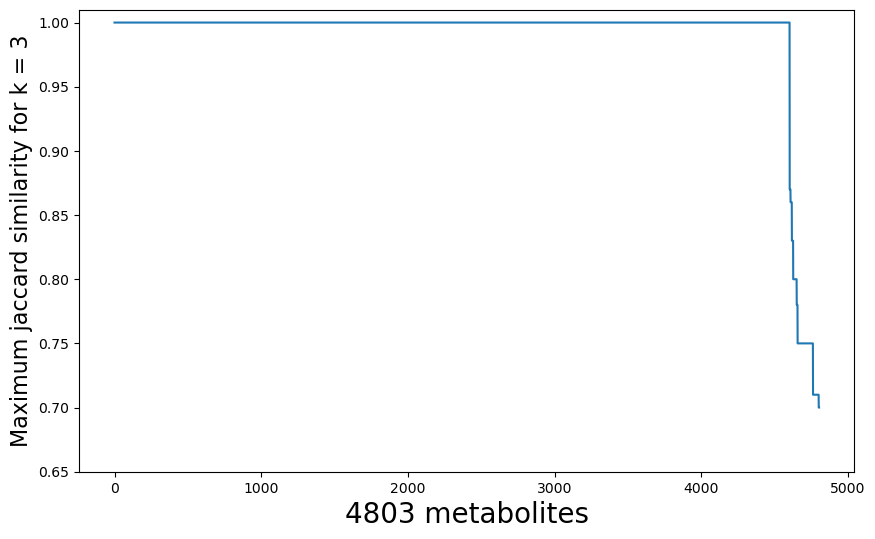

In [114]:
subset_final_df2 = final_df[final_df['max_jaccard'] >= 0.7]

ax = subset_final_df2['max_jaccard'].plot(x='metabolite_ID',figsize=(10,6))

ax.set_ylim(0.65, 1.01)
ax.set_xlabel('%s metabolites'%len(subset_final_df2['max_jaccard']),size=20)
ax.set_ylabel('Maximum jaccard similarity for k = %s'%k_value,size=16)

ax

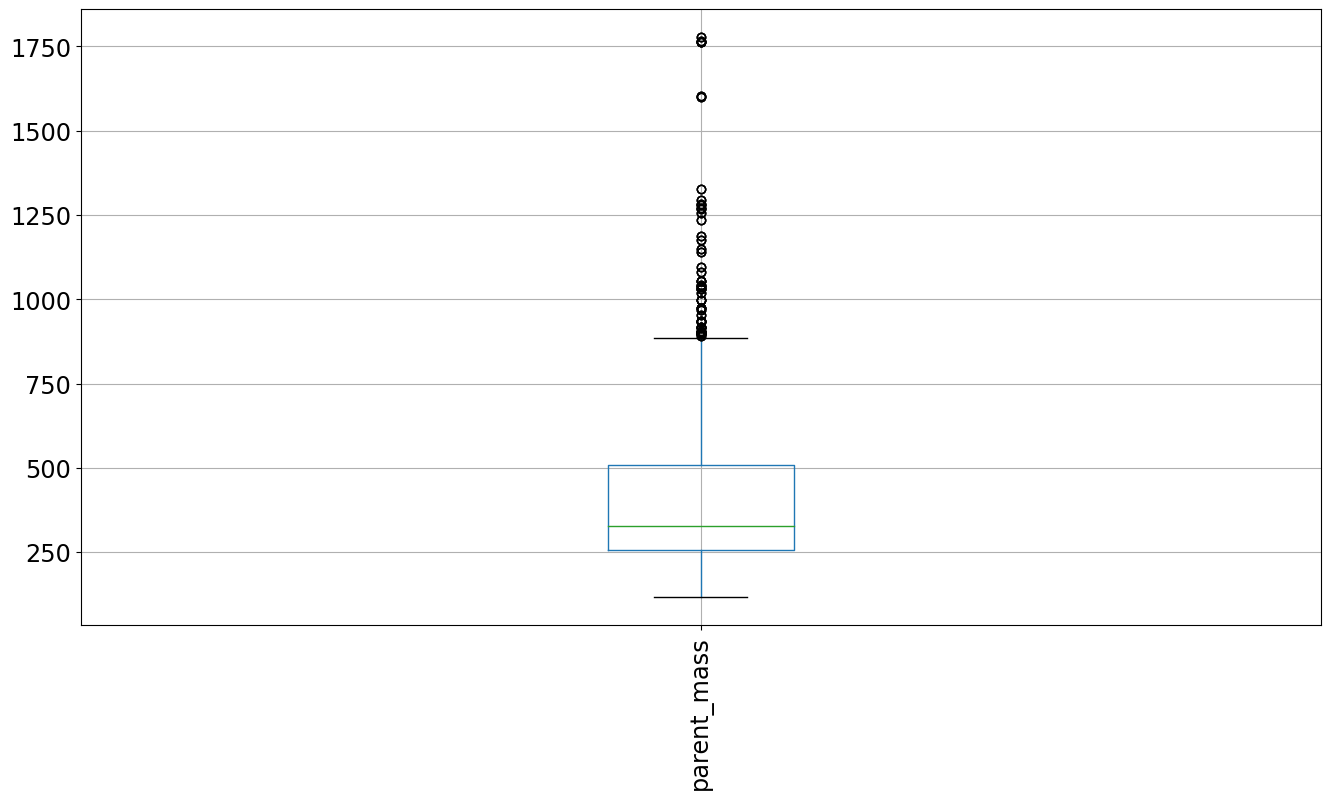

In [117]:
boxplot = pd.DataFrame(subset_final_df2['parent_mass']).boxplot(figsize=[16,8],rot=90,fontsize='xx-large')

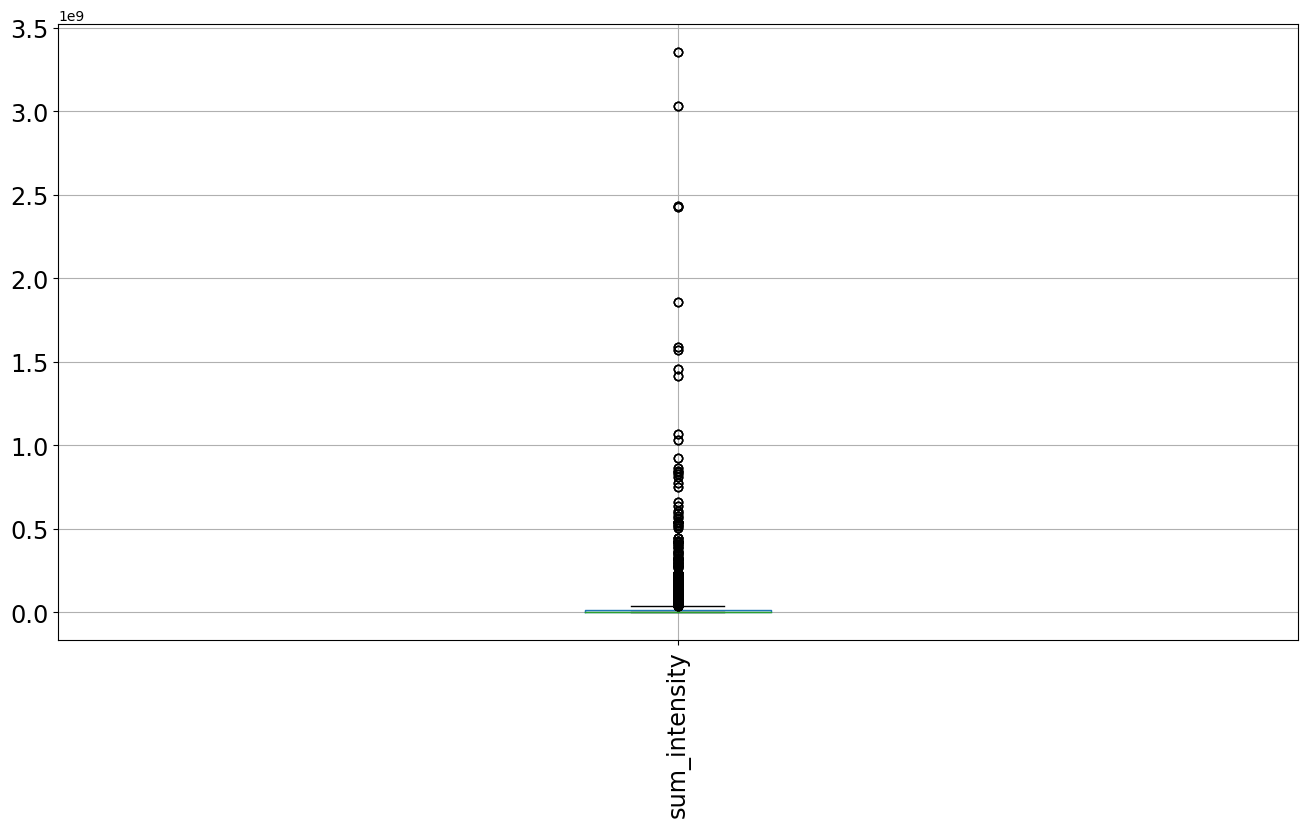

In [119]:
boxplot = pd.DataFrame(subset_final_df2['sum_intensity']).boxplot(figsize=[16,8],rot=90,fontsize='xx-large')

## 6) Evaluation with new BGC_GNPS matching file

In [61]:
def get_mibig_info(ccmsid, ccmsid_mibig_dict, mibig_name_dict):
    """
    Retrieve MIBiG BGC ID and name for a given GNPS spectrum ID (CCMS ID).
    
    Parameters:
    - ccmsid: str, GNPS spectrum ID (e.g., 'CCMSLIB00010010965')
    
    Returns:
    - tuple: (MIBiG BGC ID, BGC name) or (None, None) if not found
    """
    if ccmsid in ccmsid_mibig_dict:
        mibig_id = ccmsid_mibig_dict[ccmsid]
        bgc_name = mibig_name_dict.get(mibig_id, "Unknown BGC")
        print(f"GNPS Spectrum ID: {ccmsid} → MIBiG BGC ID: {mibig_id}, Name: {bgc_name}")
        return mibig_id, bgc_name
    else:
        print(f"GNPS Spectrum ID: {ccmsid} not found in the mapping.")
        return None, None


In [62]:
get_mibig_info('CCMSLIB00004681475', ccmsid_mibig_dict, mibig_name_dict)

GNPS Spectrum ID: CCMSLIB00004681475 → MIBiG BGC ID: BGC0001088, Name: Propionyl-Albicidin


('BGC0001088', 'Propionyl-Albicidin')

In [63]:
# Address to the tsv file containing the Spectra IDs
spectra_ids_path = "/home/fab25/NPOmix_python/inputs/gnps_function/0049d68db2cc4b33a32df946a3d93ba8.tsv"
# Read the file containing GNPS spectra IDs
spectra_ids_df = pd.read_csv(spectra_ids_path, sep='\t')
print(f"Shape of spectra IDs DataFrame: {spectra_ids_df.shape}")
# Display the first few rows of the DataFrame
print("Spectra IDs DataFrame:")
display(spectra_ids_df.head())

Shape of spectra IDs DataFrame: (14171, 47)
Spectra IDs DataFrame:


,SpectrumID,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,MoleculeExplorerFiles,molecular_formula,InChIKey,InChIKey-Planar,superclass,class,subclass,npclassifier_superclass,npclassifier_class,npclassifier_pathway
0,CCMSLIB00010010789,Gly-C18:0,ESI,qTof,Crude,Dorrestein,Emily Gentry,M+H,342.300,341.293,...,0,C20H39NO3,UEYROBDNFIWNST-UHFFFAOYSA-N,UEYROBDNFIWNST,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",Fatty amides,N-acyl amines,Fatty acids
1,CCMSLIB00010010708,Asn-C14:0,ESI,qTof,Crude,Dorrestein,Emily Gentry,M+H,343.259,342.252,...,0,C18H34N2O4,XCYGCBVZSVXYON-UHFFFAOYSA-N,XCYGCBVZSVXYON,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",Fatty amides,N-acyl amines,Fatty acids
2,CCMSLIB00003137885,Spectral Match to Gabapentin from NIST14,ESI,qTof,Isolated,Data from P. Dorrestein R. Knight,Data deposited by aaksenov,2M+H,343.259,171.126,...,577,C9H17NO2,UGJMXCAKCUNAIE-UHFFFAOYSA-N,UGJMXCAKCUNAIE,Organic acids and derivatives,Carboxylic acids and derivatives,"Amino acids, peptides, and analogues",Small peptides,Aminoacids,Amino acids and Peptides
3,CCMSLIB00005464707,"""(3R)-3-((3R,5S,7R,8R,9S,10S,13R,17R)-3,7-dihy...",ESI,qTof,crude,Dorrestein,Emily Gentry,M-2H2O+H,343.263,378.277,...,0,C23H38O4,QYYDXDSPYPOWRO-AYTZMJRQSA-N,QYYDXDSPYPOWRO,Lipids and lipid-like molecules,Steroids and steroid derivatives,"Bile acids, alcohols and derivatives",Steroids,Cholane steroids,Terpenoids
4,CCMSLIB00005464707,"""(3R)-3-((3R,5S,7R,8R,9S,10S,13R,17R)-3,7-dihy...",ESI,qTof,crude,Dorrestein,Emily Gentry,M-2H2O+H,343.263,378.277,...,0,C23H38O4,QYYDXDSPYPOWRO-AYTZMJRQSA-N,QYYDXDSPYPOWRO,Lipids and lipid-like molecules,Steroids and steroid derivatives,"Bile acids, alcohols and derivatives",Steroids,Cholane steroids,Terpenoids


### 1) Take the intersection of GNPS metadata file with GNPS–MIBiG link file based on spectrum_ID

In [39]:
# Read GNPS spectrum metadata from a molecular networking job (e.g., class annotations, library hits)
spectra_info = pd.read_csv("./inputs/gnps_function/0049d68db2cc4b33a32df946a3d93ba8.tsv", sep='\t')

# Read the curated GNPS–MIBiG link file (maps MS/MS spectra to MIBiG BGCs)
mibig_links = pd.read_csv("matched_mibig_gnps_update.tsv", sep='\t')

# Merge the two DataFrames on spectrum ID:
merged = spectra_info.merge(mibig_links, left_on="SpectrumID", right_on="# mgf_spectrum_id")

# Display the first 5 rows of the merged DataFrame to verify the result
merged.head()


,SpectrumID,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,npclassifier_superclass,npclassifier_class,npclassifier_pathway,# mgf_spectrum_id,mgf_inchikey,mgf_smiles,mibig_id,mibig_name,mibig_inchi,mibig_smiles
0,CCMSLIB00004695861,Mycophenolic Acid,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF004798,[M+K]+,359.089,0.0,...,Cyclic polyketides,Phthalide derivatives,Polyketides,CCMSLIB00004695861,HPNSFSBZBAHARI-RUDMXATFSA-N,NaN,BGC0000104,Mycophenolic acid,HPNSFSBZBAHARI-RUDMXATFSA-N,COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C
1,CCMSLIB00004695861,Mycophenolic Acid,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF004798,[M+K]+,359.089,0.0,...,Cyclic polyketides,Phthalide derivatives,Polyketides,CCMSLIB00004695861,HPNSFSBZBAHARI-RUDMXATFSA-N,NaN,BGC0001677,mycophenolic acid,HPNSFSBZBAHARI-RUDMXATFSA-N,COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C
2,CCMSLIB00004695861,Mycophenolic Acid,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF004798,[M+K]+,359.089,0.0,...,Cyclic polyketides,Phthalide derivatives,Polyketides,CCMSLIB00004695861,HPNSFSBZBAHARI-RUDMXATFSA-N,NaN,BGC0000104,Mycophenolic acid,HPNSFSBZBAHARI-RUDMXATFSA-N,COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C
3,CCMSLIB00004695861,Mycophenolic Acid,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF004798,[M+K]+,359.089,0.0,...,Cyclic polyketides,Phthalide derivatives,Polyketides,CCMSLIB00004695861,HPNSFSBZBAHARI-RUDMXATFSA-N,NaN,BGC0001677,mycophenolic acid,HPNSFSBZBAHARI-RUDMXATFSA-N,COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C
4,CCMSLIB00004695861,Mycophenolic Acid,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF004798,[M+K]+,359.089,0.0,...,Cyclic polyketides,Phthalide derivatives,Polyketides,CCMSLIB00004695861,HPNSFSBZBAHARI-RUDMXATFSA-N,NaN,BGC0000104,Mycophenolic acid,HPNSFSBZBAHARI-RUDMXATFSA-N,COC1=C(C\C=C(/C)CCC(O)=O)C(O)=C2C(=O)OCC2=C1C


In [40]:
spectra_info.shape, nodes_df.shape, mibig_links.shape, merged.shape

((14171, 47), (186163, 29), (2978, 7), (80, 54))

In [41]:
nodes_df.head()

,AllGroups,DefaultGroups,EvenOdd,G1,G2,G3,G4,G5,G6,GNPSLinkout_Cluster,...,SpectrumID,UniqueFileSources,UniqueFileSourcesCount,cluster index,componentindex,number of spectra,parent mass,precursor charge,precursor mass,sum(precursor intensity)
0,,G1,1,8,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Blongum44Bv1.3.mzXML|Bact_sp_9_1_42FAA_V2.3.mz...,7,2,-1,8,84.043,0,84.043,12004.0
1,,G1,1,14,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM6v1.2.mzXML|Bact_cacc_CL03T12C61_V1.3.mzX...,12,3,-1,14,84.043,0,84.043,23389.0
2,,G1,1,4,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Acti_vis_C505_V3.3.mzXML|Bact_sp_1_1_6_V2.3.mz...,4,5,-1,4,84.043,0,84.043,8576.0
3,,G1,1,21,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,SspCM7v1.2.mzXML|SspCM6v1.2.mzXML|Bact_cacc_CL...,12,6,1488,21,84.044,0,84.044,48410.0
4,,G1,1,15,0,0,0,0,0,https://gnps.ucsd.edu//ProteoSAFe/result.jsp?t...,...,NaN,Bact_cacc_CL03T12C61_V1.3.mzXML|Bact_sp_9_1_42...,12,11,1488,15,84.043,0,84.043,35506.0


In [42]:
# Extract required columns from the nodes_df (spectral nodes) DataFrame
# From nodes_df get only those rows where the 'LibraryID' is not NaN
annotated_nodes_df = nodes_df[['cluster index', 'LibraryID','SpectrumID']].dropna()
# Display the first few rows of the annotated nodes DataFrame
annotated_nodes_df.head()

,cluster index,LibraryID,SpectrumID
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557
171,7209,Benzoic acid,CCMSLIB00006359930
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912


In [43]:
# Rename the columns for clarity
annotated_nodes_df.columns = ['CCMS_ID', 'LibraryID','SpectrumID']
# print shape 
print(f"Shape of annotated nodes DataFrame: {annotated_nodes_df.shape}")
# Display the first few rows of the cleaned annotated nodes DataFrame
annotated_nodes_df.head()


Shape of annotated nodes DataFrame: (14171, 3)


,CCMS_ID,LibraryID,SpectrumID
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557
171,7209,Benzoic acid,CCMSLIB00006359930
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912


### 2) Find the BGC per spectrum from the new gnps_bgc_matched file 

In [44]:
dir_matched = '/home/fab25/datasets/gnps_mibig_match/gnps_mibig_match_from_original_json01.csv'
gnps_bgc_df = pd.read_csv(dir_matched)
gnps_bgc_df.head()

,spectrum_id,Compound_Name,Precursor_MZ,ExactMass,Smiles,INCHI,InChIKey_smiles,inchikey_connectivity,BGC_accession,BGC_accessions
0,CCMSLIB00000001552,Hectochlorin,667.115,0.000,C[C@H]1[C@@H](OC(C2=CSC([C@H](C(C)(OC(C3=CSC([...,,USXIYWCPCGVOKF-LERJCCFDSA-N,USXIYWCPCGVOKF,BGC0001000,['BGC0001000']
1,CCMSLIB00000001553,Hectochlorin,689.000,664.108,C[C@H]1[C@@H](OC(=O)C2=CSC(=N2)[C@H](C(OC(=O)C...,"InChI=1S/C27H34Cl2N2O9S2/c1-13-17(9-8-10-27(7,...",USXIYWCPCGVOKF-NOENWEJRSA-N,USXIYWCPCGVOKF,BGC0001000,['BGC0001000']
2,CCMSLIB00000001555,Hectochlorin,665.115,0.000,C[C@H]1[C@H](CCCC(C)(Cl)Cl)OC(=O)C2=CSC(=N2)[C...,"InChI=1S/C27H34Cl2N2O9S2/c1-13-17(9-8-10-27(7,...",USXIYWCPCGVOKF-NOENWEJRSA-N,USXIYWCPCGVOKF,BGC0001000,['BGC0001000']
3,CCMSLIB00000001558,Hectochlorin,687.000,0.000,C[C@H]1[C@H](CCCC(C)(Cl)Cl)OC(=O)C2=CSC(=N2)[C...,"InChI=1S/C27H34Cl2N2O9S2/c1-13-17(9-8-10-27(7,...",USXIYWCPCGVOKF-NOENWEJRSA-N,USXIYWCPCGVOKF,BGC0001000,['BGC0001000']
4,CCMSLIB00000001560,Jamaicamide A,569.000,566.155,C[C@H]1C=CC(=O)N1C(=O)/C=C(\CCNC(=O)CC/C=C/C(C...,InChI=1S/C27H36BrClN2O4/c1-21(12-14-23(20-29)1...,NAIKIJSSBJHCBL-VIPNTUGYSA-N,NAIKIJSSBJHCBL,BGC0001001,['BGC0001001']


In [45]:
# Find the BGC per SpectrumID from annotated_nodes_df
# Search for the SpectrumID in the gnps_bgc_df dataframe spectrum_id column
# If found, append the BGC from BGC_accessions column (a list) to the BGC column in annotated_nodes_df
annotated_nodes_df['BGC_accessions'] = annotated_nodes_df['SpectrumID'].map(gnps_bgc_df.set_index('spectrum_id')['BGC_accessions'])

# Add Compound_Name column to annotated_nodes_df
annotated_nodes_df['Compound_Name'] = annotated_nodes_df['SpectrumID'].map(gnps_bgc_df.set_index('spectrum_id')['Compound_Name'])

# Display the first few rows of the annotated nodes DataFrame
annotated_nodes_df.head()

,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557,NaN,NaN
171,7209,Benzoic acid,CCMSLIB00006359930,NaN,NaN
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055,NaN,NaN
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430,NaN,NaN
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912,NaN,NaN


In [46]:
# Print number of nodes (spectra) with BGC
print(f"Number of nodes (spectra) with BGC: {annotated_nodes_df[annotated_nodes_df['BGC_accessions'].notna()].shape[0]}")
annotated_nodes_df[annotated_nodes_df['BGC_accessions'].notna()]


Number of nodes (spectra) with BGC: 186


,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name
3117,42965,CITRULLINE - 30.0 eV,CCMSLIB00005883647,['BGC0000895'],CITRULLINE - 30.0 eV
3364,47833,geraniol,CCMSLIB00006364245,['BGC0002846'],geraniol
7025,110408,Clavulanic acid,CCMSLIB00005435929,"['BGC0000841', 'BGC0000844', 'BGC0000845']",Clavulanic acid
8946,159170,NCGC00385936-01!4-hydroxy-3-(3-methylbut-2-eny...,CCMSLIB00000845988,['BGC0002290'],NCGC00385936-01!4-hydroxy-3-(3-methylbut-2-eny...
12499,220204,Spectral Match to Pyocyanin from NIST14,CCMSLIB00003137540,['BGC0000936'],Spectral Match to Pyocyanin from NIST14
...,...,...,...,...,...
184386,2678961,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...
184389,2678970,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...
184405,2679067,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...
184461,2679585,Putative orfamide B,CCMSLIB00004679299,"['BGC0000398', 'BGC0002779']",Putative orfamide B


In [48]:
# Save the annotated_nodes_df to a pickle file for later use
annotated_nodes_df.to_pickle(os.path.join(output_path, 'annotated_nodes_df.pkl'))

In [49]:
output_path

'/home/fab25/NPOmix_python/saved_files'

### 3) Add BGCs and predicted GCF data into the file 

In [51]:
final_df_grouped = final_df.groupby('metabolite_ID')['predicted_GCF'].apply(list).reset_index()
final_df_grouped.head()

,metabolite_ID,predicted_GCF
0,5668,"[GCF460, GCF473, GCF72]"
1,7209,"[GCF192, GCF192, GCF192]"
2,10731,"[GCF460, GCF473, GCF72]"
3,10763,"[GCF81, GCF81, GCF81]"
4,11636,"[GCF248, GCF138, GCF247]"


In [52]:
# Add Compound_Name column to annotated_nodes_df
annotated_nodes_df['predicted_GCF'] = annotated_nodes_df['CCMS_ID'].map(final_df_grouped.set_index('metabolite_ID')['predicted_GCF'])

# Display the first few rows of the annotated nodes DataFrame
annotated_nodes_df.head()

,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name,predicted_GCF
86,5668,Levulinic acid - 40.0 eV,CCMSLIB00006124557,NaN,NaN,"[GCF460, GCF473, GCF72]"
171,7209,Benzoic acid,CCMSLIB00006359930,NaN,NaN,"[GCF192, GCF192, GCF192]"
211,10731,Metformin - 30.0 eV,CCMSLIB00006118055,NaN,NaN,"[GCF460, GCF473, GCF72]"
212,10732,Maltol - 40.0 eV,CCMSLIB00006114430,NaN,NaN,NaN
220,10763,Massbank:PB000516 Indole-3-carbinol|H-indol-3-...,CCMSLIB00000221912,NaN,NaN,"[GCF81, GCF81, GCF81]"


In [53]:
# Save the annotated_nodes_df to a pickle file for later use
annotated_nodes_df.to_pickle(os.path.join(output_path, 'annotated_nodes_df.pkl'))

In [55]:
# Just keep those rows which are not nan in BGC_accessions predicted_GCF columns (in both columns)
merged = annotated_nodes_df[annotated_nodes_df['BGC_accessions'].notna() & annotated_nodes_df['predicted_GCF'].notna()]

# Display the first few rows of the annotated nodes DataFrame
merged

,CCMS_ID,LibraryID,SpectrumID,BGC_accessions,Compound_Name,predicted_GCF
7025,110408,Clavulanic acid,CCMSLIB00005435929,"['BGC0000841', 'BGC0000844', 'BGC0000845']",Clavulanic acid,"[GCF5, GCF3, GCF2]"
12499,220204,Spectral Match to Pyocyanin from NIST14,CCMSLIB00003137540,['BGC0000936'],Spectral Match to Pyocyanin from NIST14,"[GCF446, GCF362, GCF360]"
21502,400892,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF190, GCF92, GCF92]"
21509,400932,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF93, GCF93, GCF93]"
21511,400944,2-heptylquinolin-4(1H)-one,CCMSLIB00005723688,['BGC0000922'],2-heptylquinolin-4(1H)-one,"[GCF70, GCF62, GCF70]"
...,...,...,...,...,...,...
180695,2633816,lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,CCMSLIB00000577587,['BGC0002914'],lyngbyastatin_3_15247_dereplictor_pv_3.52136e-23,"[GCF601, GCF606, GCF596]"
184376,2678907,Putative orfamide C,CCMSLIB00004679300,['BGC0000399'],Putative orfamide C,"[GCF445, GCF439, GCF360]"
184389,2678970,Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,CCMSLIB00000577607,['BGC0002889'],Actinomycin_X2;_Actinomycin_V;_Actinomyc_28731...,"[GCF459, GCF332, GCF333]"
184461,2679585,Putative orfamide B,CCMSLIB00004679299,"['BGC0000398', 'BGC0002779']",Putative orfamide B,"[GCF445, GCF360, GCF439]"


### 4) Label prediction

In [65]:
# For every SpectrumID in the merged file
# 1) go into the predicted_GCF column
# 2) For every GCF in the predicted_GCF column, go into the bigscape_dict2 dictionary and find the GCF (key of dictionary)
# 3) For every BGC in the GCF (key of dictionary), split it by '.' and take the first part (e.g., GCA_000737335.region031 -> GCA_000737335)
# 4) For the respective BGC look into the BGC_accessions column of that spectrum_ID and if at least one BGC is in the BGC_accessions column, 
# append it to a new column and create also a binary column (1 if the BGC is in the BGC_accessions column, 0 otherwise)
# Create new columns to store the results
merged['matched_BGC'] = ''
merged['BGC_match_binary'] = 0

# Iterate over each row in the merged file
for index, row in merged.iterrows():
    # Get the predicted GCFs for this SpectrumID
    predicted_GCFs = row['predicted_GCF']
    
    # Initialize a flag to track if a match is found
    match_found = False
    
    # Iterate over each predicted GCF
    for gcf in predicted_GCFs:
        # Get the BGCs for this GCF from the bigscape_dict2 dictionary
        bgcs = bigscape_dict2[gcf]
        
        # Iterate over each BGC
        for bgc in bgcs:
            # Split the BGC by '.' and take the first part
            bgc_short = bgc.split('.')[0]
            
            # Check if this BGC is in the BGC_accessions column for this SpectrumID
            if bgc_short in row['BGC_accessions']:
                # If it is, append it to the matched_BGC column and set the binary column to 1
                merged.at[index, 'matched_BGC'] = bgc_short
                merged.at[index, 'BGC_match_binary'] = 1
                match_found = True
                break
        
        # If a match is found, break out of the loop
        if match_found:
            break

/tmp/ipykernel_2272737/1600015880.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['matched_BGC'] = ''
/tmp/ipykernel_2272737/1600015880.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['BGC_match_binary'] = 0


In [85]:
# For every SpectrumID in the merged file
# 1) go into the predicted_GCF column
# 2) For every GCF in the predicted_GCF column, go into the bigscape_dict2 dictionary and find the GCF (key of dictionary)
# 3) For every BGC in the GCF (key of dictionary), split it by '.' and take the first part (e.g., GCA_000737335.region031 -> GCA_000737335)
# 4) For the respective BGC look into the BGC_accessions column of that spectrum_ID and if at least one BGC is in the BGC_accessions column, 
# append it to a new column and create also a binary column (1 if the BGC is in the BGC_accessions column, 0 otherwise)
# Create new columns to store the results
merged['matched_BGC'] = ''
merged['BGC_match_binary'] = 0

# Iterate over each row in the merged file
for index, row in merged.iterrows():
    # Get the predicted GCFs for this SpectrumID
    predicted_GCFs = row['predicted_GCF']
    
    # Initialize a flag to track if a match is found
    match_found = False
    
    # Iterate over each predicted GCF
    for gcf in predicted_GCFs:
        # Get the BGCs for this GCF from the bigscape_dict2 dictionary
        bgcs = bigscape_dict2[gcf]
        
        # Iterate over each BGC
        for bgc in bgcs:
            # Split the BGC by '.' and take the first part
            bgc_short = bgc.split('.')[0]
            
            # Check if this BGC is in the BGC_accessions column for this SpectrumID
            if bgc_short in row['BGC_accessions']:
                # If it is, append it to the matched_BGC column and set the binary column to 1
                merged.at[index, 'matched_BGC'] = bgc_short
                merged.at[index, 'BGC_match_binary'] = 1
                match_found = True
                break
        
        # If a match is found, break out of the loop
        if match_found:
            break

/tmp/ipykernel_3340059/1600015880.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['matched_BGC'] = ''
/tmp/ipykernel_3340059/1600015880.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged['BGC_match_binary'] = 0


In [86]:
merged['BGC_match_binary'].value_counts()

BGC_match_binary
0    118
1     16
Name: count, dtype: int64

In [100]:
# Print number of true positives
print("Number of true positives:", merged[merged['BGC_match_binary'] == 1].shape[0])
# Print number of false positives
print("Number of false positives:", merged[merged['BGC_match_binary'] == 0].shape[0])

Number of true positives: 16
Number of false positives: 118


#### Test for the misannotation in the reference file 

In [68]:
merged.loc[merged['mibig_id']=='BGC0000070']

,SpectrumID,Compound_Name,Ion_Source,Instrument,Compound_Source,PI,Data_Collector,Adduct,Precursor_MZ,ExactMass,...,npclassifier_superclass,npclassifier_class,npclassifier_pathway,# mgf_spectrum_id,mgf_inchikey,mgf_smiles,mibig_id,mibig_name,mibig_inchi,mibig_smiles
64,CCMSLIB00004709011,norlichexanthone,NaN,ESI-QFT,isolated,MoNA,MoNA:VF-NPL-QEHF017948,[M-H]-,257.046,0.0,...,Xanthones,Methyl xanthones,Polyketides,CCMSLIB00004709011,AQZHBCDRWFMXIN-UHFFFAOYSA-N,NaN,BGC0000070,norlichexanthone,AQZHBCDRWFMXIN-UHFFFAOYSA-N,CC1=CC(=CC2=C1C(=O)C3=C(C=C(C=C3O2)O)O)O


In [103]:
# Search for the CCMSLIB00004709011 sepctrum in the gnps_bgc_df dataframe spectrum_id column
filtered_df = gnps_bgc_df[gnps_bgc_df['spectrum_id'].str.contains('CCMSLIB00004709011')]
filtered_df

,spectrum_id,Compound_Name,Precursor_MZ,ExactMass,Smiles,INCHI,InChIKey_smiles,inchikey_connectivity,BGC_accession,BGC_accessions


## Original version

In [16]:
final_df = final_df[final_df['max_jaccard'] > 0]
final_df = final_df.sort_values(by='max_jaccard',ascending=False)
final_df = final_df.explode('predicted_GCF')
final_df = final_df.reset_index(drop=True)

final_df

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit
0,5668,GCF460,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
1,5668,GCF473,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
2,5668,GCF72,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV
3,985146,GCF473,1.00,339.289,38484500.0,"Spectral Match to 13-Docosenamide, (Z)- from N..."
4,985146,GCF460,1.00,339.289,38484500.0,"Spectral Match to 13-Docosenamide, (Z)- from N..."
...,...,...,...,...,...,...
16081,607888,GCF106,0.01,275.703,780421.0,Trp-C4:0
16082,607888,GCF209,0.01,275.703,780421.0,Trp-C4:0
16083,2590656,GCF106,0.01,941.511,3933280.0,NCGC00385557-01_C48H76O18_
16084,2590656,GCF106,0.01,941.511,3933280.0,NCGC00385557-01_C48H76O18_


In [19]:
mibig_df = pd.read_csv("./matched_mibig_gnps_update.tsv",sep='\t')

mibig_name_dict = dict(zip(mibig_df['mibig_id'],mibig_df['mibig_name']))

ccmsid_mibig_dict = dict(zip(mibig_df['# mgf_spectrum_id'],mibig_df['mibig_id']))

ccmsid_mibig_dict

{'CCMSLIB00000001552': 'BGC0001000',
 'CCMSLIB00000006865': 'BGC0000001',
 'CCMSLIB00000075009': 'BGC0000950',
 'CCMSLIB00000075016': 'BGC0000950',
 'CCMSLIB00000075305': 'BGC0000055',
 'CCMSLIB00000075306': 'BGC0000055',
 'CCMSLIB00000075307': 'BGC0000706',
 'CCMSLIB00000075308': 'BGC0000706',
 'CCMSLIB00000075309': 'BGC0000724',
 'CCMSLIB00000075310': 'BGC0000724',
 'CCMSLIB00000075311': 'BGC0000455',
 'CCMSLIB00000075312': 'BGC0000455',
 'CCMSLIB00000075313': 'BGC0001453',
 'CCMSLIB00000075320': 'BGC0000985',
 'CCMSLIB00000075321': 'BGC0000985',
 'CCMSLIB00000075322': 'BGC0000985',
 'CCMSLIB00000075323': 'BGC0000985',
 'CCMSLIB00000075324': 'BGC0000985',
 'CCMSLIB00000075325': 'BGC0000985',
 'CCMSLIB00000075331': 'BGC0000016',
 'CCMSLIB00000075332': 'BGC0000016',
 'CCMSLIB00000077217': 'BGC0001310',
 'CCMSLIB00000077218': 'BGC0001310',
 'CCMSLIB00000078898': 'BGC0000901',
 'CCMSLIB00000081213': 'BGC0000389',
 'CCMSLIB00000081265': 'BGC0000820',
 'CCMSLIB00000081266': 'BGC0000820',
 

In [87]:
mf_length_dict = {}

for key in mf_dict:
    for clusterindex in mf_dict[key]:
        mf_length_dict[clusterindex] = len(mf_dict[key])

mf_length_dict

{2: 1,
 3: 1,
 5: 1,
 5604: 16,
 15876: 16,
 6: 16,
 3784: 16,
 177928: 16,
 11: 16,
 12204: 16,
 15884: 16,
 64785: 16,
 3987: 16,
 5589: 16,
 6421: 16,
 87671: 16,
 2128764: 16,
 64829: 16,
 3806: 16,
 18: 1,
 36: 1,
 47: 1,
 63: 1,
 384: 1,
 473: 1,
 731: 1,
 732: 1,
 733: 1,
 734: 1,
 741: 1,
 742: 1,
 743: 1,
 745: 4,
 5075: 4,
 3357: 4,
 3783: 4,
 753: 1,
 1153: 1,
 1354: 1,
 1416: 1,
 13128: 3,
 3316: 3,
 174591: 3,
 3317: 1,
 3319: 1,
 3327: 1,
 3328: 2,
 10098: 2,
 3329: 1,
 3342: 1,
 3344: 1,
 3399: 1,
 3601: 1,
 3615: 1,
 3616: 1,
 3631: 1,
 3722: 6,
 7346: 6,
 7347: 6,
 7349: 6,
 7350: 6,
 7351: 6,
 3764: 1,
 3777: 9,
 11169: 9,
 10856: 9,
 4529: 9,
 5078: 9,
 3769: 9,
 12763: 9,
 12284: 9,
 5279: 9,
 3779: 1,
 3809: 1,
 3907: 1,
 5062: 1,
 5074: 1,
 5076: 1,
 17490: 2,
 5102: 2,
 13121: 9,
 13127: 9,
 5127: 9,
 13132: 9,
 13133: 9,
 13135: 9,
 13136: 9,
 5242: 9,
 5245: 9,
 5173: 1,
 5249: 1,
 5275: 1,
 5278: 1,
 5288: 1,
 6012: 2,
 5292: 2,
 5296: 1,
 5302: 1,
 5306: 1,
 

In [20]:
mf_length_dict = {}

for key in mf_dict:
    for clusterindex in mf_dict[key]:
        mf_length_dict[clusterindex] = len(mf_dict[key])

mf_length_dict

{2: 1,
 3: 1,
 5: 1,
 5604: 16,
 15876: 16,
 6: 16,
 3784: 16,
 177928: 16,
 11: 16,
 12204: 16,
 15884: 16,
 64785: 16,
 3987: 16,
 5589: 16,
 6421: 16,
 87671: 16,
 2128764: 16,
 64829: 16,
 3806: 16,
 18: 1,
 36: 1,
 47: 1,
 63: 1,
 384: 1,
 473: 1,
 731: 1,
 732: 1,
 733: 1,
 734: 1,
 741: 1,
 742: 1,
 743: 1,
 745: 4,
 5075: 4,
 3357: 4,
 3783: 4,
 753: 1,
 1153: 1,
 1354: 1,
 1416: 1,
 13128: 3,
 3316: 3,
 174591: 3,
 3317: 1,
 3319: 1,
 3327: 1,
 3328: 2,
 10098: 2,
 3329: 1,
 3342: 1,
 3344: 1,
 3399: 1,
 3601: 1,
 3615: 1,
 3616: 1,
 3631: 1,
 3722: 6,
 7346: 6,
 7347: 6,
 7349: 6,
 7350: 6,
 7351: 6,
 3764: 1,
 3777: 9,
 11169: 9,
 10856: 9,
 4529: 9,
 5078: 9,
 3769: 9,
 12763: 9,
 12284: 9,
 5279: 9,
 3779: 1,
 3809: 1,
 3907: 1,
 5062: 1,
 5074: 1,
 5076: 1,
 17490: 2,
 5102: 2,
 13121: 9,
 13127: 9,
 5127: 9,
 13132: 9,
 13133: 9,
 13135: 9,
 13136: 9,
 5242: 9,
 5245: 9,
 5173: 1,
 5249: 1,
 5275: 1,
 5278: 1,
 5288: 1,
 6012: 2,
 5292: 2,
 5296: 1,
 5302: 1,
 5306: 1,
 

In [21]:
import re

gcf_class_dict = {}

for key in bigscape_dict2:
    class_dict = {}
    for bgc_index in bigscape_dict2[key]:
        class1 = bigscape_df[bigscape_df['Clustername_1'] == bgc_index]['Combined_group']
        if len(class1) == 0:
            class2 = bigscape_df[bigscape_df['Clustername_2'] == bgc_index]['Combined_group']
            if bgc_index not in class_dict:
                class_dict[bgc_index] = class2
        else:
            if bgc_index not in class_dict:
                class_dict[bgc_index] = class1
    combined_class = []
    for bgc_index in class_dict:
        combined_class.append(str(np.unique(class_dict[bgc_index])))
    sub_combined_class = re.sub(r'[\W_]', ',', str(combined_class))
    final_combined_class = str(np.unique(sub_combined_class.split(',')))[4:-1]
    gcf_class_dict[key] = final_combined_class
    
gcf_class_dict

{'GCF1': "'siderophore'",
 'GCF2': "'NRPS' 'blactam' 'nrps' 'other'",
 'GCF3': "'NRPS' 'nrps'",
 'GCF4': "'NRPS' 'T1PKS' 'siderophore'",
 'GCF5': "'indole'",
 'GCF6': "'LAP' 'bacteriocin' 'ectoine' 'n' 'thiopeptide'",
 'GCF7': "'T1PKS'",
 'GCF8': "'NRPS' 'T1PKS' 'lanthipeptide' 'like' 'n' 'nrps' 't1pks'",
 'GCF9': "'T1PKS'",
 'GCF10': "'T3PKS'",
 'GCF11': "'bacteriocin' 'terpene'",
 'GCF12': "'NRPS' 'like'",
 'GCF13': "'NRPS'",
 'GCF14': "'NRPS' 'nrps'",
 'GCF15': "'lanthipeptide'",
 'GCF16': "'terpene'",
 'GCF17': "'NRPS' 'bacteriocin' 'siderophore'",
 'GCF18': "'NRPS'",
 'GCF19': "'bacteriocin'",
 'GCF20': "'PKS' 'like'",
 'GCF21': "'bacteriocin'",
 'GCF22': "'NRPS' 'T1PKS' 'T2PKS' 'T3PKS' 'betalactone' 'butyrolactone'\n 'lanthipeptide' 'like' 'n' 'siderophore' 't2pks' 'terpene'",
 'GCF23': "'NRPS' 'PKS' 'T1PKS' 'bacteriocin' 'blactam' 'like' 'n' 'nrps' 't1pks'\n 'transAT'",
 'GCF24': "'NRPS' 'T1PKS'",
 'GCF25': "'NRPS' 'nrps'",
 'GCF26': "'NRPS' 'betalactone' 'like' 'n' 'terpene'",


In [22]:
np_classifier_df = pd.read_csv("./inputs/gnps_function/0049d68db2cc4b33a32df946a3d93ba8.tsv",sep='\t',index_col=0)

npsuperclass_dict = dict(zip(np_classifier_df['#Scan#'],np_classifier_df['npclassifier_superclass']))
npclass_dict = dict(zip(np_classifier_df['#Scan#'],np_classifier_df['npclassifier_class']))

npsuperclass_dict

{1001025: 'Fatty amides',
 1001746: 'Fatty amides',
 1001762: 'Small peptides',
 1001805: 'Steroids',
 1001912: 'Steroids',
 1001983: 'Steroids',
 1001993: 'Steroids',
 1002039: 'Steroids',
 1002120: 'Steroids',
 1002195: 'Steroids',
 1002269: 'Steroids',
 1002282: 'Steroids',
 1002447: nan,
 1002548: 'Steroids',
 1002619: 'Steroids',
 1002640: 'Steroids',
 1002817: nan,
 1002914: nan,
 1002974: nan,
 1002998: nan,
 1003063: nan,
 1003396: nan,
 1003421: nan,
 1003921: nan,
 1004307: 'Fatty acyls',
 1004407: 'Oligopeptides|Small peptides',
 1004410: 'Naphthalenes',
 1004449: nan,
 1004476: 'Flavonoids',
 1004685: nan,
 1004813: 'Tryptophan alkaloids',
 1005336: nan,
 1005447: nan,
 1005508: nan,
 100559: 'Small peptides',
 1005677: 'Diterpenoids',
 1005732: 'Fatty amides',
 1005788: 'Lysine alkaloids',
 1005815: 'Lysine alkaloids',
 1006148: 'Diterpenoids',
 1006254: 'Diterpenoids',
 1007928: nan,
 1007939: 'Fatty amides',
 1008731: nan,
 1008769: nan,
 1008780: nan,
 1008803: nan,
 10

In [23]:
true_count = 0
total_count = 0
mibig_col,bgc_count_col,ms_count_col,gcf_class_col,npclass_col,npsuper_col = [],[],[],[],[],[]
match_dict = {}

for i,r in final_df[final_df['max_jaccard'] >= 0].iterrows():
    libhit = str(nodes_df[nodes_df['cluster index'] == r['metabolite_ID']]['LibraryID'].item())
    specID = str(nodes_df[nodes_df['cluster index'] == r['metabolite_ID']]['SpectrumID'].item())
    bgchits_list = []
    bgc_count_col.append(len(bigscape_dict2[r['predicted_GCF']]))
    ms_count_col.append(mf_length_dict[r['metabolite_ID']])
    gcf_class_col.append(gcf_class_dict[r['predicted_GCF']])
    npsuper_col.append(npsuperclass_dict[r['metabolite_ID']])
    npclass_col.append(npclass_dict[r['metabolite_ID']])
    for bgc in bigscape_dict2[r['predicted_GCF']]:
        bgc = bgc.split('.')[0]
        if 'BGC' in bgc:
            if bgc in mibig_name_dict:
                bgchits_list.append(mibig_name_dict[bgc])
                if specID in ccmsid_mibig_dict:
                    match_dict[r['metabolite_ID']] = False
                    if ccmsid_mibig_dict[specID] == bgc:
                        total_count += 1
                        true_count += 1
                        match_dict[r['metabolite_ID']] = True
                        print(r['metabolite_ID'],'true',r['predicted_GCF'],specID,ccmsid_mibig_dict[specID],bgc,libhit)
                    else:
                        total_count += 1
                        print(r['metabolite_ID'],'false',r['predicted_GCF'],specID,ccmsid_mibig_dict[specID],bgc,'mibig=%s'%mibig_name_dict[bgc],'gnps=%s'%libhit)
    if len(bgchits_list) > 0:
        mibig_col.append(bgchits_list[0])
    else:
        mibig_col.append('no_hit')

print(true_count,total_count)
print('Average precision of %s when links are counted seperately' % round(true_count/total_count*100,2))

1312036 false GCF3 CCMSLIB00005435928 BGC0000845 BGC0000373 mibig=Holomycin gnps=Clavulanic acid
1312036 true GCF2 CCMSLIB00005435928 BGC0000845 BGC0000845 Clavulanic acid
1312036 false GCF2 CCMSLIB00005435928 BGC0000845 BGC0000844 mibig=Clavulanic acid gnps=Clavulanic acid
1312036 false GCF2 CCMSLIB00005435928 BGC0000845 BGC0000319 mibig=Cephamycin C gnps=Clavulanic acid
1395846 false GCF3 CCMSLIB00005435951 BGC0000384 BGC0000373 mibig=Holomycin gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF2 CCMSLIB00005435951 BGC0000384 BGC0000845 mibig=clavulanic acid gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF2 CCMSLIB00005435951 BGC0000384 BGC0000844 mibig=Clavulanic acid gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1395846 false GCF2 CCMSLIB00005435951 BGC0000384 BGC0000319 mibig=Cephamycin C gnps=Lyngbyatoxin A M+H-CO putative or close isomer
1308027 false GCF3 CCMSLIB00005435928 BGC0000845 BGC0000373 mibig=Holomycin gnps=Clavulanic acid
1

2202347 false GCF149 CCMSLIB00004695118 BGC0001572 BGC0000664 mibig=isorenieratene gnps=deferrioxamine E
28 87
Average precision of 32.18 when links are counted seperately


In [24]:
final_count = 0

for key in match_dict:
    if match_dict[key] == True:
        final_count += 1
    
print('Final average precision of %s out of %s' % (round(final_count/len(match_dict)*100,2),len(match_dict)))

Final average precision of 46.43 out of 28


In [25]:
final_df['MIBiG_lib_hit'] = mibig_col
final_df['GCF_length'] = bgc_count_col
final_df['MF_length'] = ms_count_col
final_df['GCF_class'] = gcf_class_col
final_df['NP_superclass'] = npsuper_col
final_df['NP_class'] = npclass_col

final_df

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit,MIBiG_lib_hit,GCF_length,MF_length,GCF_class,NP_superclass,NP_class
0,5668,GCF460,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,2,2,'terpene',Fatty Acids and Conjugates,Oxo fatty acids
1,5668,GCF473,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,2,2,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',Fatty Acids and Conjugates,Oxo fatty acids
2,5668,GCF72,1.00,116.426,3114140.0,Levulinic acid - 40.0 eV,no_hit,28,2,'KS' 'NRPS' 'T1PKS' 'hglE' 'hglks' 't1pks',Fatty Acids and Conjugates,Oxo fatty acids
3,985146,GCF473,1.00,339.289,38484500.0,"Spectral Match to 13-Docosenamide, (Z)- from N...",no_hit,2,21,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',NaN,NaN
4,985146,GCF460,1.00,339.289,38484500.0,"Spectral Match to 13-Docosenamide, (Z)- from N...",no_hit,2,21,'terpene',NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
16081,607888,GCF106,0.01,275.703,780421.0,Trp-C4:0,no_hit,45,4,'arylpolyene' 'other',Small peptides,Dipeptides
16082,607888,GCF209,0.01,275.703,780421.0,Trp-C4:0,no_hit,8,4,'NRPS' 'microviridin' 'nrps',Small peptides,Dipeptides
16083,2590656,GCF106,0.01,941.511,3933280.0,NCGC00385557-01_C48H76O18_,no_hit,45,63,'arylpolyene' 'other',Triterpenoids,Oleanane triterpenoids
16084,2590656,GCF106,0.01,941.511,3933280.0,NCGC00385557-01_C48H76O18_,no_hit,45,63,'arylpolyene' 'other',Triterpenoids,Oleanane triterpenoids


In [26]:
final_df[final_df['GNPS_lib_hit'].str.contains('Rosamicin')]

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit,MIBiG_lib_hit,GCF_length,MF_length,GCF_class,NP_superclass,NP_class
3489,2118735,GCF347,1.0,582.364,633747.0,Rosamicin,rosamicin,5,25,'T1PKS' 't1pks',Macrolides,Tylosins
3490,2118735,GCF347,1.0,582.364,633747.0,Rosamicin,rosamicin,5,25,'T1PKS' 't1pks',Macrolides,Tylosins
3491,2118735,GCF346,1.0,582.364,633747.0,Rosamicin,no_hit,2,25,'NRPS' 'T1PKS',Macrolides,Tylosins
7509,2118716,GCF347,0.5,583.416,8212370.0,Rosamicin,rosamicin,5,25,'T1PKS' 't1pks',Macrolides,Tylosins
7510,2118716,GCF347,0.5,583.416,8212370.0,Rosamicin,rosamicin,5,25,'T1PKS' 't1pks',Macrolides,Tylosins
7511,2118716,GCF352,0.5,583.416,8212370.0,Rosamicin,no_hit,2,25,'NRPS' 'T1PKS' 'lanthipeptide',Macrolides,Tylosins


In [27]:
final_df[final_df['MIBiG_lib_hit'].str.contains('Jamaicamide')]

,metabolite_ID,predicted_GCF,max_jaccard,parent_mass,sum_intensity,GNPS_lib_hit,MIBiG_lib_hit,GCF_length,MF_length,GCF_class,NP_superclass,NP_class
2118,2353640,GCF471,1.0,694.405,609634.0,Palmyramide A in #1921,Jamaicamide C,2,7,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
2120,2353640,GCF471,1.0,694.405,609634.0,Palmyramide A in #1921,Jamaicamide C,2,7,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
2337,2301836,GCF471,1.0,664.985,16045600.0,Hectochlorin,Jamaicamide C,2,15,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
2339,2301836,GCF471,1.0,664.985,16045600.0,Hectochlorin,Jamaicamide C,2,15,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
2343,2304029,GCF471,1.0,666.963,12736700.0,Hectochlorin,Jamaicamide C,2,15,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,Oligopeptides,Cyclic peptides|Depsipeptides
2345,2304029,GCF471,1.0,666.963,12736700.0,Hectochlorin,Jamaicamide C,2,15,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,Oligopeptides,Cyclic peptides|Depsipeptides
3045,1846348,GCF471,1.0,489.080,2999380.0,Jamaicamide B,Jamaicamide C,2,4,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
3047,1846348,GCF471,1.0,489.080,2999380.0,Jamaicamide B,Jamaicamide C,2,4,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
3315,2089827,GCF471,1.0,568.970,3637270.0,Jamaicamide A,Jamaicamide C,2,4,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN
3317,2089827,GCF471,1.0,568.970,3637270.0,Jamaicamide A,Jamaicamide C,2,4,'NRPS' 'PKS' 'T1PKS' 'T3PKS' 'like' 'nrps' 't1...,NaN,NaN


In [37]:
edges_df = final_df[['metabolite_ID','predicted_GCF','max_jaccard']]
edges_df = edges_df[edges_df['max_jaccard'] >= 0.7]

edges_df.to_csv("%sedges_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index=False)

edges_df

,metabolite_ID,predicted_GCF,max_jaccard
0,5668,GCF460,1.00
1,5668,GCF473,1.00
2,5668,GCF72,1.00
3,985146,GCF473,1.00
4,985146,GCF460,1.00
...,...,...,...
5188,1270551,GCF254,0.71
5189,1270551,GCF254,0.71
5190,968111,GCF184,0.71
5191,968111,GCF184,0.71


In [46]:
pre_node_df1 = final_df[['metabolite_ID','parent_mass','sum_intensity','GNPS_lib_hit','MF_length','NP_superclass']]
pre_node_df2 = final_df[['predicted_GCF','MIBiG_lib_hit','GCF_length','GCF_class']]
pre_node_df2 = pre_node_df2.rename(columns={'predicted_GCF':'metabolite_ID', 'MIBiG_lib_hit':'GNPS_lib_hit',
                                            'GCF_length':'MF_length', 'GCF_class':'NP_superclass'})

node_df = pd.concat([pre_node_df2, pre_node_df1], sort=False).fillna(0)
node_df.to_csv("%snodes_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index=False)

node_df

,metabolite_ID,GNPS_lib_hit,MF_length,NP_superclass,parent_mass,sum_intensity
0,GCF460,no_hit,2,'terpene',0.000,0.0
1,GCF473,no_hit,2,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',0.000,0.0
2,GCF72,no_hit,28,'KS' 'NRPS' 'T1PKS' 'hglE' 'hglks' 't1pks',0.000,0.0
3,GCF473,no_hit,2,'NRPS' 'T1PKS' 'microviridin' 'nrps' 't1pks',0.000,0.0
4,GCF460,no_hit,2,'terpene',0.000,0.0
...,...,...,...,...,...,...
16081,607888,Trp-C4:0,4,Small peptides,275.703,780421.0
16082,607888,Trp-C4:0,4,Small peptides,275.703,780421.0
16083,2590656,NCGC00385557-01_C48H76O18_,63,Triterpenoids,941.511,3933280.0
16084,2590656,NCGC00385557-01_C48H76O18_,63,Triterpenoids,941.511,3933280.0


In [43]:
subset_final_df1 = final_df[final_df['MIBiG_lib_hit'] != 'no_hit']

subset_final_df1.to_csv("%ssubset_final_df-derep-NPOmix1.0-%s.txt"%(results_folder,current_date),sep="\t",index_label=False)

<Axes: xlabel='4791 metabolites', ylabel='Maximum jaccard similarity for k = 3'>

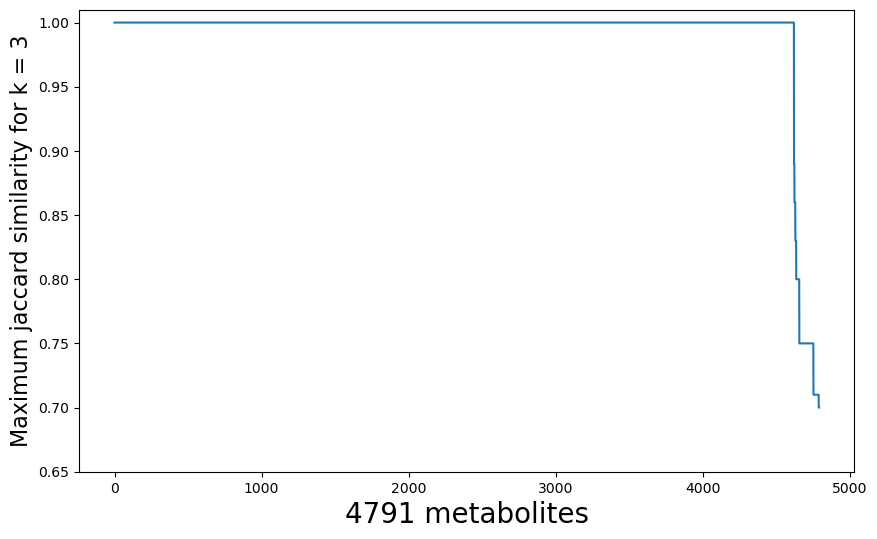

In [92]:
subset_final_df2 = final_df[final_df['max_jaccard'] >= 0.7]

ax = subset_final_df2['max_jaccard'].plot(x='metabolite_ID',figsize=(10,6))

ax.set_ylim(0.65, 1.01)
ax.set_xlabel('%s metabolites'%len(subset_final_df2['max_jaccard']),size=20)
ax.set_ylabel('Maximum jaccard similarity for k = %s'%k_value,size=16)

ax

<Axes: xlabel='5193 metabolites', ylabel='Maximum jaccard similarity for k = 3'>

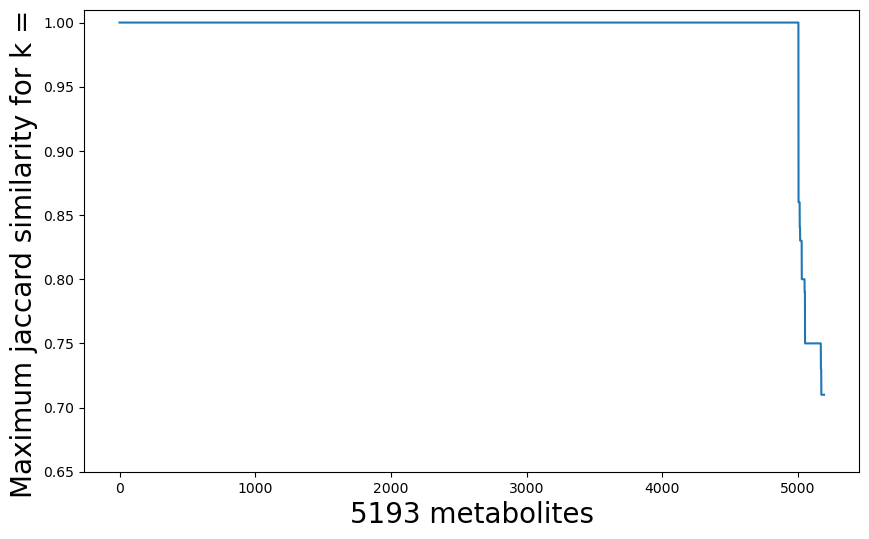

In [29]:
subset_final_df2 = final_df[final_df['max_jaccard'] >= 0.7]

ax = subset_final_df2['max_jaccard'].plot(x='metabolite_ID',figsize=(10,6))

ax.set_ylim(0.65, 1.01)
ax.set_xlabel('%s metabolites'%len(subset_final_df2['max_jaccard']),size=20)
ax.set_ylabel('Maximum jaccard similarity for k = %s'%k_value,size=20)

ax

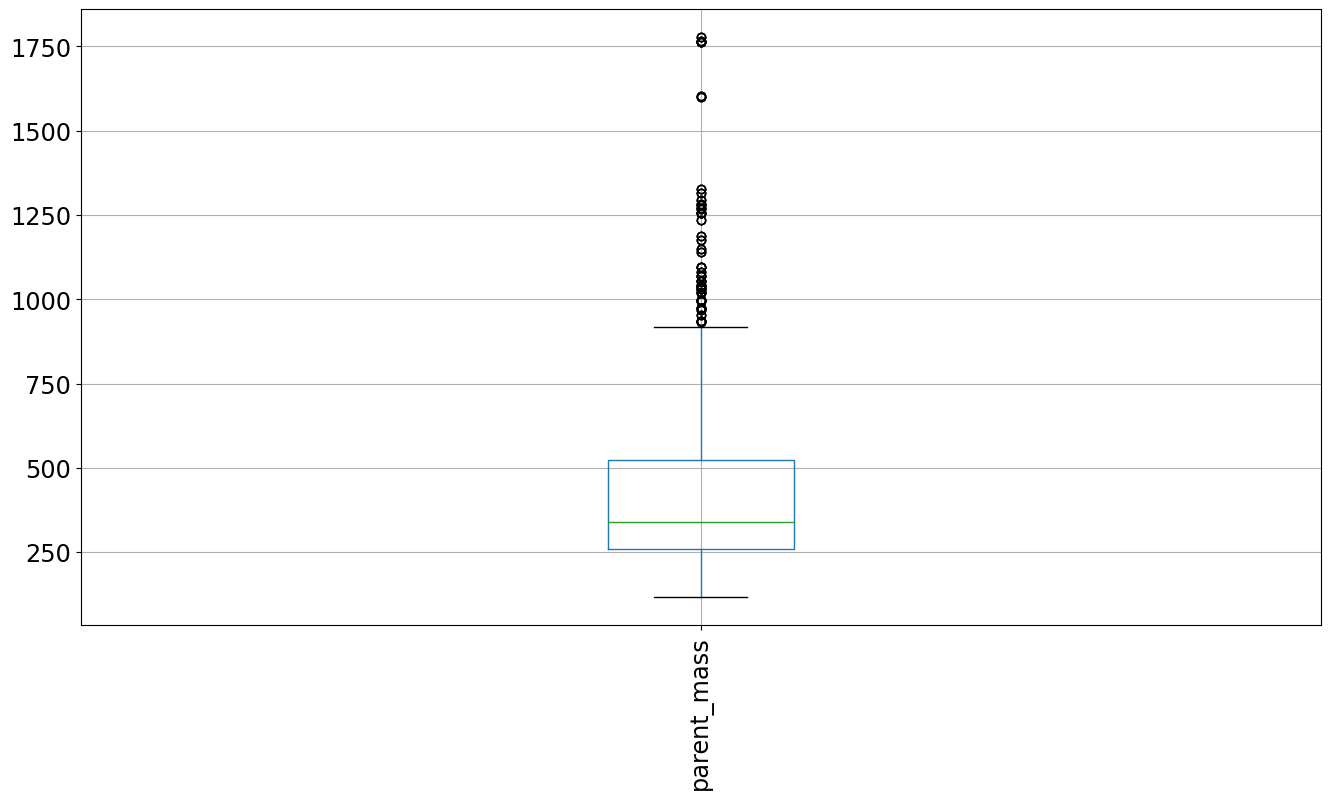

In [30]:
boxplot = pd.DataFrame(subset_final_df2['parent_mass']).boxplot(figsize=[16,8],rot=90,fontsize='xx-large')

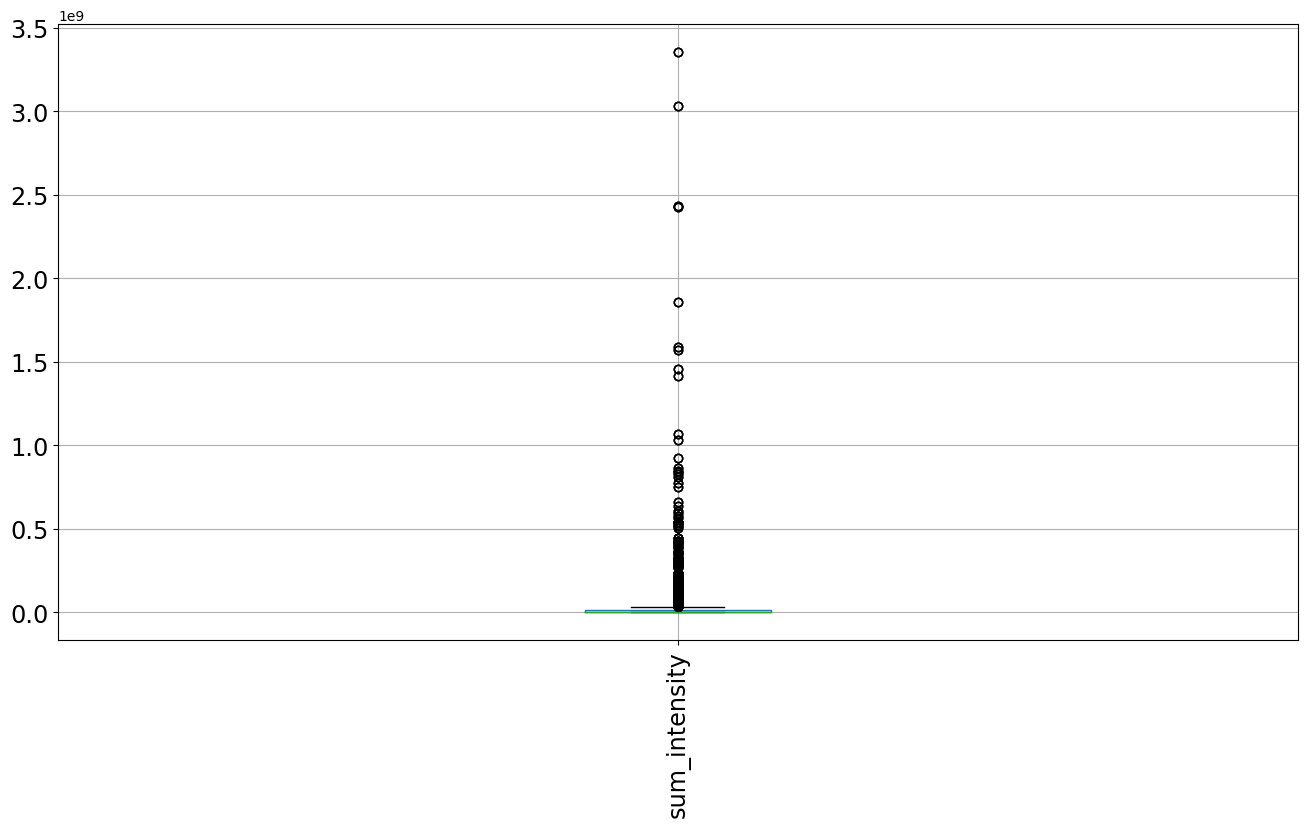

In [31]:
boxplot = pd.DataFrame(subset_final_df2['sum_intensity']).boxplot(figsize=[16,8],rot=90,fontsize='xx-large')

In [32]:
end = time.time()
hours, rem = divmod(end-start, 3600)
minutes, seconds = divmod(rem, 60)
run_time = "{:0>2}:{:0>2}:{:05.2f}".format(int(hours),int(minutes),seconds)
print(run_time)

00:15:11.99
